In [8]:
import pandas as pd
import ast
import matplotlib.pyplot as plt
import re
data = pd.read_csv('/Users/krymmd/Library/CloudStorage/OneDrive-IdahoNationalLaboratory/Documents/MoltenSaltPropnet/data/new_mstdb_janz_with_ionic_polarizability.csv')


In [9]:
data.head()

,System,Mol Mass,Mol Frac,Melt(K),Boil(K),rho_a,rho_b,mu1_a,mu1_b,mu2_a,...,electronegativity_element,ionic_charge_element,atomic_radius_element[Angstrom],ionic_radius_element[Angstrom],covalent_radius_element[Angstrom],first_ionization_energy[kJ_per_mol],symbol,atomic_radius_components[Angstrom],ionic_polarizability_sum_components,ionic_polarizability_mean_components
0,AlCl3,133.3405,Pure Salt,465.0,453.0,2.56,0.002710,0.00228,19400.0,NaN,...,"{'Al': 1.61, 'Cl': 3.16}","{'Al': '3+', 'Cl': '1-'}","{'Al': 1.18, 'Cl': 0.79}","{'Al': 1.25, 'Cl': 1.0}","{'Al': 1.18, 'Cl': 0.99}","{'Al': 577.5, 'Cl': 1251.2}","{'Al': 'Al', 'Cl': 'Cl'}",3.55,12.888750,3.222188
1,BeCl2,79.9182,Pure Salt,688.0,760.0,2.28,0.001100,NaN,NaN,NaN,...,"{'Be': 1.57, 'Cl': 3.16}","{'Be': '2+', 'Cl': '1-'}","{'Be': 1.12, 'Cl': 0.79}","{'Be': 1.05, 'Cl': 1.0}","{'Be': 0.9, 'Cl': 0.99}","{'Be': 899.5, 'Cl': 1251.2}","{'Be': 'Be', 'Cl': 'Cl'}",2.70,7.410920,2.470307
2,BeF2,47.0090,Pure Salt,821.2,1442.0,1.97,0.000015,NaN,NaN,-8.120,...,"{'Be': 1.57, 'F': 3.98}","{'Be': '2+', 'F': '1-'}","{'Be': 1.12, 'F': 0.42}","{'Be': 1.05, 'F': 0.5}","{'Be': 0.9, 'F': 0.71}","{'Be': 899.5, 'F': 1681.0}","{'Be': 'Be', 'F': 'F'}",1.96,3.898795,1.299598
3,CaCl2,110.9840,Pure Salt,1045.0,2230.0,2.53,0.000423,NaN,NaN,-0.545,...,"{'Ca': 1.0, 'Cl': 3.16}","{'Ca': '2+', 'Cl': '1-'}","{'Ca': 1.94, 'Cl': 0.79}","{'Ca': 1.8, 'Cl': 1.0}","{'Ca': 1.74, 'Cl': 0.99}","{'Ca': 589.8, 'Cl': 1251.2}","{'Ca': 'Ca', 'Cl': 'Cl'}",3.52,25.583188,8.527729
4,CaF2,78.0748,Pure Salt,1692.0,2724.0,3.18,0.000391,0.10000,47600.0,NaN,...,"{'Ca': 1.0, 'F': 3.98}","{'Ca': '2+', 'F': '1-'}","{'Ca': 1.94, 'F': 0.42}","{'Ca': 1.8, 'F': 0.5}","{'Ca': 1.74, 'F': 0.71}","{'Ca': 589.8, 'F': 1681.0}","{'Ca': 'Ca', 'F': 'F'}",2.78,22.071063,7.357021


In [10]:
pred_cols = data.columns[3:16]
data_cols = data.columns[17:].drop('symbol')

anion_filter = 'Cl'
flag = data['System'].apply(lambda x: True if anion_filter in x else False)
data = data[flag]
data

,System,Mol Mass,Mol Frac,Melt(K),Boil(K),rho_a,rho_b,mu1_a,mu1_b,mu2_a,...,electronegativity_element,ionic_charge_element,atomic_radius_element[Angstrom],ionic_radius_element[Angstrom],covalent_radius_element[Angstrom],first_ionization_energy[kJ_per_mol],symbol,atomic_radius_components[Angstrom],ionic_polarizability_sum_components,ionic_polarizability_mean_components
0,AlCl3,133.3405,Pure Salt,465.0,453.0,2.5600,0.002710,2.280000e-03,19400.00,NaN,...,"{'Al': 1.61, 'Cl': 3.16}","{'Al': '3+', 'Cl': '1-'}","{'Al': 1.18, 'Cl': 0.79}","{'Al': 1.25, 'Cl': 1.0}","{'Al': 1.18, 'Cl': 0.99}","{'Al': 577.5, 'Cl': 1251.2}","{'Al': 'Al', 'Cl': 'Cl'}",3.55,12.888750,3.222188
1,BeCl2,79.9182,Pure Salt,688.0,760.0,2.2800,0.001100,NaN,NaN,NaN,...,"{'Be': 1.57, 'Cl': 3.16}","{'Be': '2+', 'Cl': '1-'}","{'Be': 1.12, 'Cl': 0.79}","{'Be': 1.05, 'Cl': 1.0}","{'Be': 0.9, 'Cl': 0.99}","{'Be': 899.5, 'Cl': 1251.2}","{'Be': 'Be', 'Cl': 'Cl'}",2.70,7.410920,2.470307
3,CaCl2,110.9840,Pure Salt,1045.0,2230.0,2.5300,0.000423,NaN,NaN,-0.545,...,"{'Ca': 1.0, 'Cl': 3.16}","{'Ca': '2+', 'Cl': '1-'}","{'Ca': 1.94, 'Cl': 0.79}","{'Ca': 1.8, 'Cl': 1.0}","{'Ca': 1.74, 'Cl': 0.99}","{'Ca': 589.8, 'Cl': 1251.2}","{'Ca': 'Ca', 'Cl': 'Cl'}",3.52,25.583188,8.527729
5,GdCl3,263.6090,Pure Salt,875.0,1868.0,4.1500,0.000673,NaN,NaN,6.380,...,"{'Gd': 1.2, 'Cl': 3.16}","{'Gd': '3+', 'Cl': '1-'}","{'Gd': 2.33, 'Cl': 0.79}","{'Gd': 1.8, 'Cl': 1.0}","{'Gd': nan, 'Cl': 0.99}","{'Gd': 593.4, 'Cl': 1251.2}","{'Gd': 'Gd', 'Cl': 'Cl'}",4.70,31.106816,7.776704
7,KCl,74.5513,Pure Salt,1042.7,1688.0,2.1400,0.000583,7.080000e-02,23900.00,NaN,...,"{'K': 0.82, 'Cl': 3.16}","{'K': '1+', 'Cl': '1-'}","{'K': 2.43, 'Cl': 0.79}","{'K': 2.2, 'Cl': 1.0}","{'K': 1.96, 'Cl': 0.99}","{'K': 418.8, 'Cl': 1251.2}","{'K': 'K', 'Cl': 'Cl'}",3.22,41.629516,20.814758
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4865,UCl3,NaN,Pure Salt,NaN,NaN,13.6520,0.007943,NaN,NaN,NaN,...,"{'U': 1.38, 'Cl': 3.16}","{'U': '3+, 4+, 6+', 'Cl': '1-'}","{'U': 1.75, 'Cl': 0.79}","{'U': 1.75, 'Cl': 1.0}","{'U': nan, 'Cl': 0.99}","{'U': 597.6, 'Cl': 1251.2}","{'U': 'U', 'Cl': 'Cl'}",4.12,53.383047,13.345762
4866,UCl4,NaN,Pure Salt,NaN,NaN,5.2508,0.001945,NaN,NaN,NaN,...,"{'U': 1.38, 'Cl': 3.16}","{'U': '3+, 4+, 6+', 'Cl': '1-'}","{'U': 1.75, 'Cl': 0.79}","{'U': 1.75, 'Cl': 1.0}","{'U': nan, 'Cl': 0.99}","{'U': 597.6, 'Cl': 1251.2}","{'U': 'U', 'Cl': 'Cl'}",4.91,55.844062,11.168812
4869,YCl3,NaN,Pure Salt,NaN,NaN,3.0070,0.000500,NaN,NaN,NaN,...,"{'Y': 1.22, 'Cl': 3.16}","{'Y': '3+', 'Cl': '1-'}","{'Y': 2.12, 'Cl': 0.79}","{'Y': 1.85, 'Cl': 1.0}","{'Y': 1.62, 'Cl': 0.99}","{'Y': 600.0, 'Cl': 1251.2}","{'Y': 'Y', 'Cl': 'Cl'}",4.49,26.352435,6.588109
4872,ZnCl2,NaN,Pure Salt,NaN,NaN,2.8375,0.000529,9.818701e-05,96325.38,NaN,...,"{'Zn': 1.65, 'Cl': 3.16}","{'Zn': '2+', 'Cl': '1-'}","{'Zn': 1.42, 'Cl': 0.79}","{'Zn': 1.35, 'Cl': 1.0}","{'Zn': 1.31, 'Cl': 0.99}","{'Zn': 906.4, 'Cl': 1251.2}","{'Zn': 'Zn', 'Cl': 'Cl'}",3.00,11.144687,3.714896


In [11]:
data[pred_cols].head(10)

,Melt(K),Boil(K),rho_a,rho_b,mu1_a,mu1_b,mu2_a,mu2_b,mu2_c,k_a,k_b,cp_a,cp_b
0,465.0,453.0,2.56,0.002710,0.00228,19400.0,NaN,NaN,NaN,NaN,NaN,125.52000,NaN
1,688.0,760.0,2.28,0.001100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1045.0,2230.0,2.53,0.000423,NaN,NaN,-0.545,597.0,546000.0,0.568,-0.000115,102.53300,NaN
5,875.0,1868.0,4.15,0.000673,NaN,NaN,6.380,-15500.0,9800000.0,NaN,NaN,NaN,NaN
7,1042.7,1688.0,2.14,0.000583,0.07080,23900.0,NaN,NaN,NaN,0.566,-0.000170,73.59656,NaN
9,1132.0,1983.0,4.09,0.000777,0.02060,54600.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11,883.0,1655.0,1.88,0.000433,0.07260,22400.0,NaN,NaN,NaN,0.882,-0.000290,73.38320,-0.009473
13,987.0,1640.0,1.97,0.000288,0.18000,20500.0,NaN,NaN,NaN,0.224,-0.000020,92.04800,NaN
15,1073.8,1715.0,2.14,0.000543,0.08930,22000.0,NaN,NaN,NaN,0.712,-0.000180,77.76380,-0.007531
17,1031.0,1897.0,4.26,0.000930,0.08510,36900.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
data[data_cols].head(10)

,polarizability_element[10-24Cm3],atomic_mass_element,electronegativity_element,ionic_charge_element,atomic_radius_element[Angstrom],ionic_radius_element[Angstrom],covalent_radius_element[Angstrom],first_ionization_energy[kJ_per_mol],atomic_radius_components[Angstrom],ionic_polarizability_sum_components,ionic_polarizability_mean_components
0,"{'Al': 8.34, 'Cl': 2.18}","{'Al': 26.982, 'Cl': 35.453}","{'Al': 1.61, 'Cl': 3.16}","{'Al': '3+', 'Cl': '1-'}","{'Al': 1.18, 'Cl': 0.79}","{'Al': 1.25, 'Cl': 1.0}","{'Al': 1.18, 'Cl': 0.99}","{'Al': 577.5, 'Cl': 1251.2}",3.55,12.888750,3.222188
1,"{'Be': 5.6, 'Cl': 2.18}","{'Be': 9.012, 'Cl': 35.453}","{'Be': 1.57, 'Cl': 3.16}","{'Be': '2+', 'Cl': '1-'}","{'Be': 1.12, 'Cl': 0.79}","{'Be': 1.05, 'Cl': 1.0}","{'Be': 0.9, 'Cl': 0.99}","{'Be': 899.5, 'Cl': 1251.2}",2.70,7.410920,2.470307
3,"{'Ca': 25.0, 'Cl': 2.18}","{'Ca': 40.078, 'Cl': 35.453}","{'Ca': 1.0, 'Cl': 3.16}","{'Ca': '2+', 'Cl': '1-'}","{'Ca': 1.94, 'Cl': 0.79}","{'Ca': 1.8, 'Cl': 1.0}","{'Ca': 1.74, 'Cl': 0.99}","{'Ca': 589.8, 'Cl': 1251.2}",3.52,25.583188,8.527729
5,"{'Gd': 26.0, 'Cl': 2.18}","{'Gd': 157.25, 'Cl': 35.453}","{'Gd': 1.2, 'Cl': 3.16}","{'Gd': '3+', 'Cl': '1-'}","{'Gd': 2.33, 'Cl': 0.79}","{'Gd': 1.8, 'Cl': 1.0}","{'Gd': nan, 'Cl': 0.99}","{'Gd': 593.4, 'Cl': 1251.2}",4.70,31.106816,7.776704
7,"{'K': 43.4, 'Cl': 2.18}","{'K': 39.098, 'Cl': 35.453}","{'K': 0.82, 'Cl': 3.16}","{'K': '1+', 'Cl': '1-'}","{'K': 2.43, 'Cl': 0.79}","{'K': 2.2, 'Cl': 1.0}","{'K': 1.96, 'Cl': 0.99}","{'K': 418.8, 'Cl': 1251.2}",3.22,41.629516,20.814758
9,"{'La': 37.0, 'Cl': 2.18}","{'La': 138.905, 'Cl': 35.453}","{'La': 1.1, 'Cl': 3.16}","{'La': '3+', 'Cl': '1-'}","{'La': 1.95, 'Cl': 0.79}","{'La': 1.95, 'Cl': 1.0}","{'La': 1.69, 'Cl': 0.99}","{'La': 538.1, 'Cl': 1251.2}",4.32,40.775547,10.193887
11,"{'Li': 24.3, 'Cl': 2.18}","{'Li': 6.941, 'Cl': 35.453}","{'Li': 0.98, 'Cl': 3.16}","{'Li': '1+', 'Cl': '1-'}","{'Li': 1.67, 'Cl': 0.79}","{'Li': 1.45, 'Cl': 1.0}","{'Li': 1.34, 'Cl': 0.99}","{'Li': 520.2, 'Cl': 1251.2}",2.46,16.129766,8.064883
13,"{'Mg': 10.6, 'Cl': 2.18}","{'Mg': 24.305, 'Cl': 35.453}","{'Mg': 1.31, 'Cl': 3.16}","{'Mg': '2+', 'Cl': '1-'}","{'Mg': 1.45, 'Cl': 0.79}","{'Mg': 1.5, 'Cl': 1.0}","{'Mg': 1.3, 'Cl': 0.99}","{'Mg': 737.7, 'Cl': 1251.2}",3.03,12.709786,4.236595
15,"{'Na': 23.6, 'Cl': 2.18}","{'Na': 22.99, 'Cl': 35.453}","{'Na': 0.93, 'Cl': 3.16}","{'Na': '1+', 'Cl': '1-'}","{'Na': 1.9, 'Cl': 0.79}","{'Na': 1.8, 'Cl': 1.0}","{'Na': 1.54, 'Cl': 0.99}","{'Na': 495.8, 'Cl': 1251.2}",2.69,22.291571,11.145786
17,"{'Nd': 32.0, 'Cl': 2.18}","{'Nd': 144.242, 'Cl': 35.453}","{'Nd': 1.14, 'Cl': 3.16}","{'Nd': '3+, 4+', 'Cl': '1-'}","{'Nd': 2.06, 'Cl': 0.79}","{'Nd': 1.85, 'Cl': 1.0}","{'Nd': nan, 'Cl': 0.99}","{'Nd': 533.1, 'Cl': 1251.2}",4.43,39.383047,9.845762


# Polarizability Study

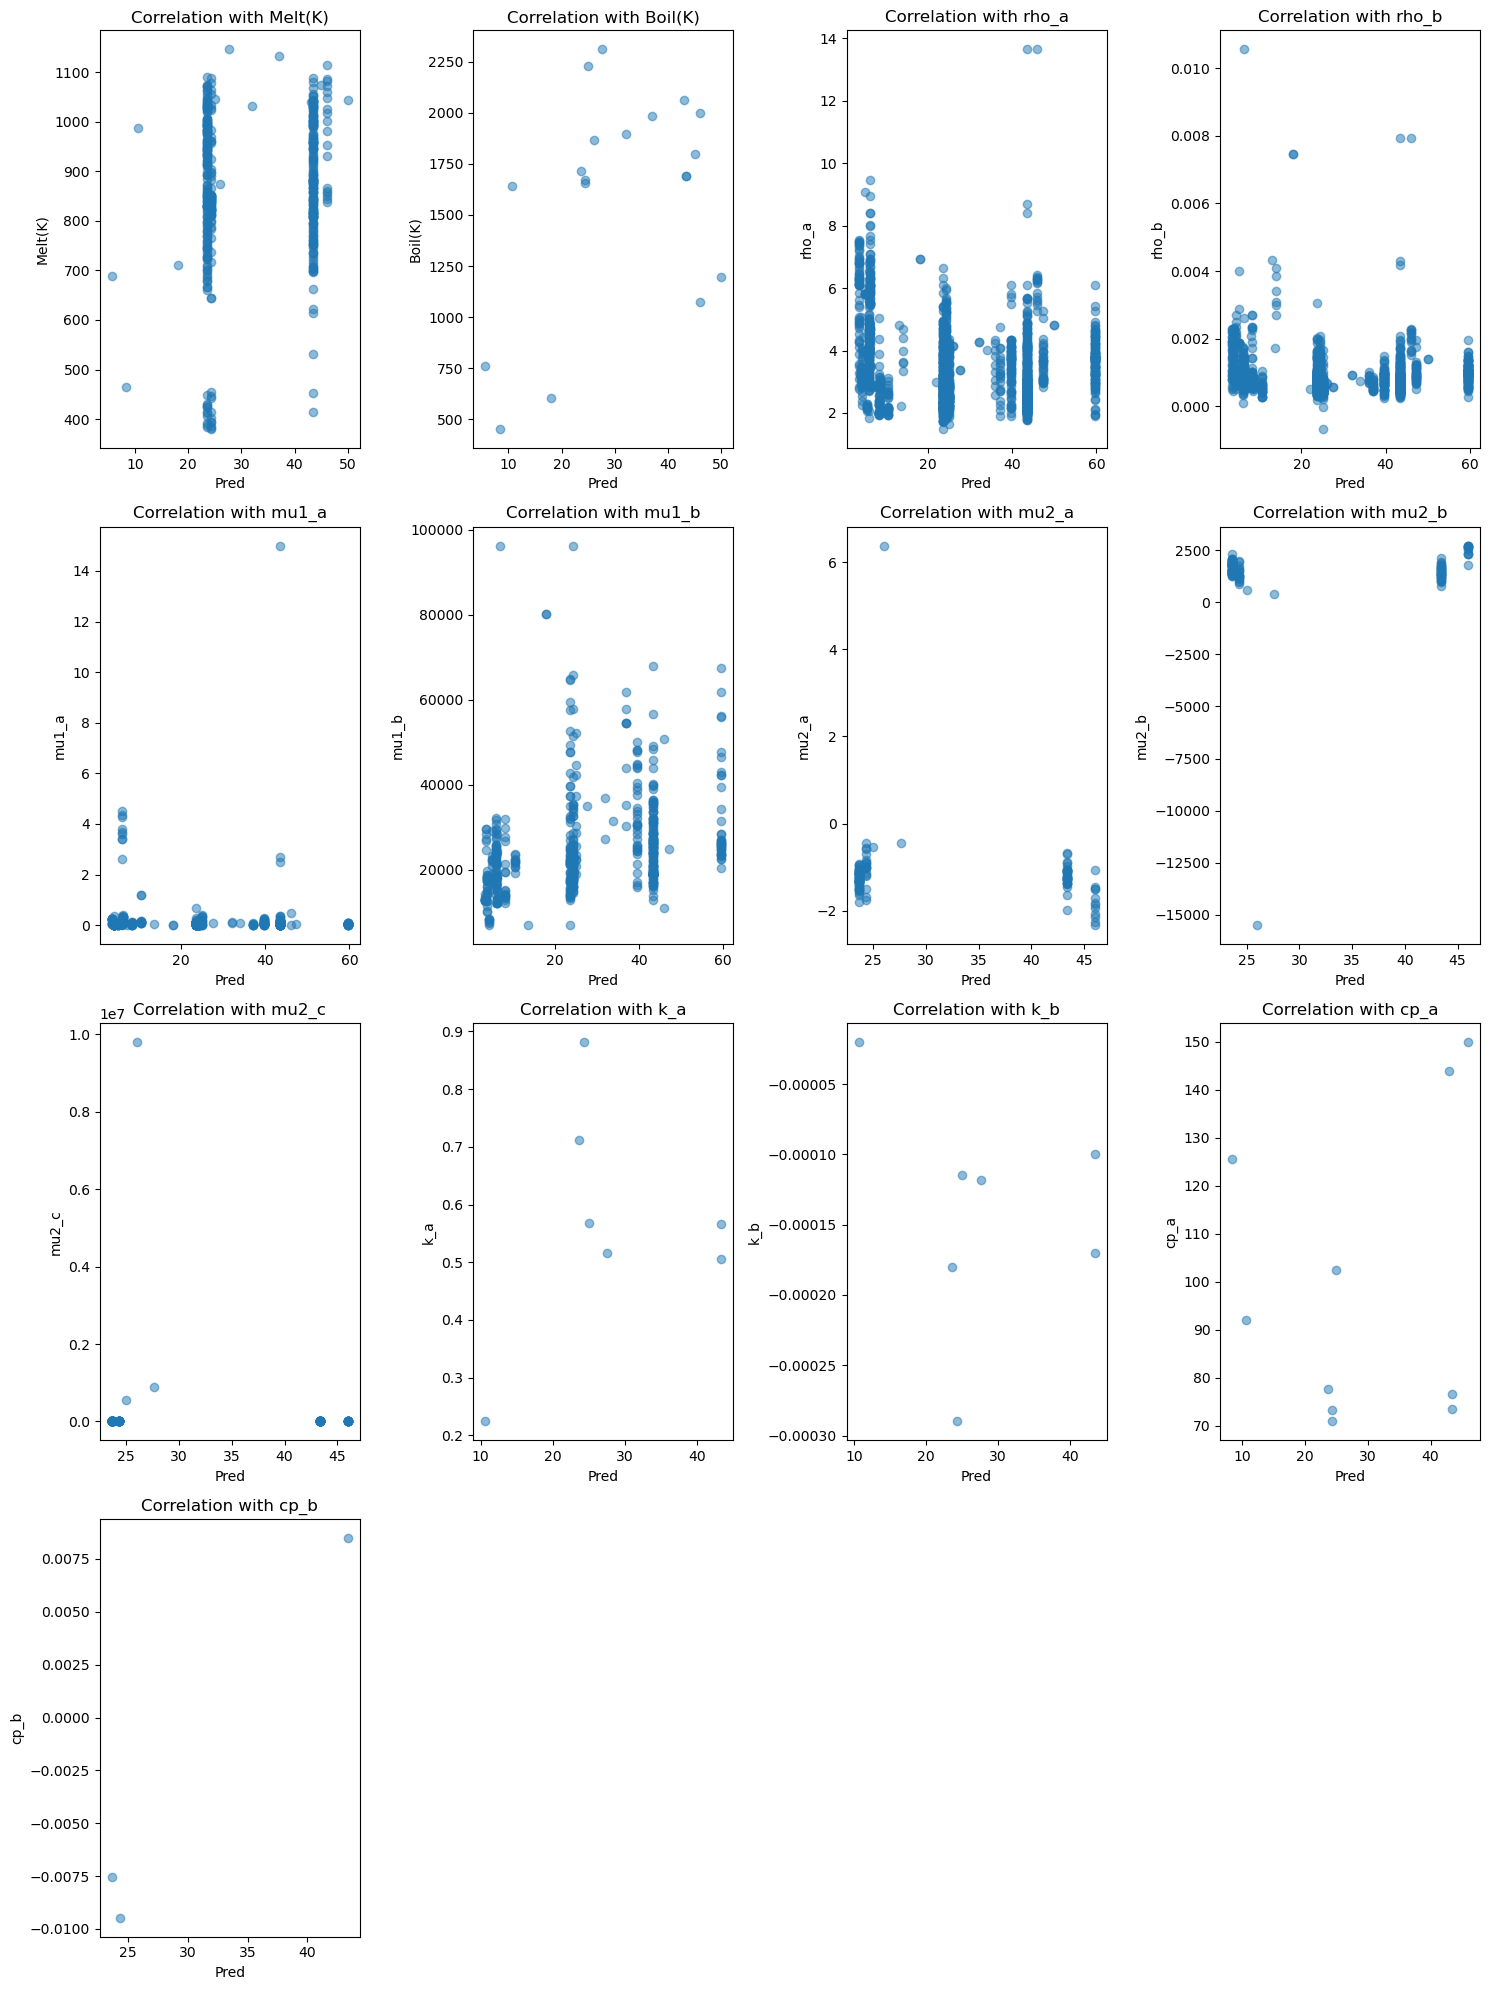

Correlation Table:
        Correlation
Melt(K)    0.171815
Boil(K)     0.40471
rho_a     -0.234156
rho_b     -0.151213
mu1_a     -0.067765
mu1_b       0.31348
mu2_a     -0.151414
mu2_b      0.095356
mu2_c      -0.05341
k_a        0.227003
k_b       -0.218612
cp_a       0.193443
cp_b        0.99159


In [13]:
def safe_eval(x):
    try:
        value = ast.literal_eval(x)
        keys = value.keys()
        cats = [key for key in keys if key != 'Cl']
        return value[cats[0]]
    except Exception as e:
        print(f"Error evaluating {x}: {e}")
        return None

# Assuming 'data' is your DataFrame and 'data_cols' and 'pred_cols' are lists containing the relevant columns.
pred = data[data_cols[0]].apply(safe_eval)
tgt = data[pred_cols]

# Prepare the plotting grid
n_cols = 4
n_rows = (len(tgt.columns) + 1) // n_cols + 1

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

correlation_table = pd.DataFrame(index=tgt.columns, columns=['Correlation'])

for i, column in enumerate(tgt.columns):
    not_nan_indices = tgt[column].notna()
    filtered_pred = pred[not_nan_indices]
    filtered_tgt = tgt[column][not_nan_indices]

    axes[i].scatter(filtered_pred, filtered_tgt, alpha=0.5)
    axes[i].set_title(f'Correlation with {column}')
    axes[i].set_xlabel('Pred')
    axes[i].set_ylabel(column)

    # Calculate and store the correlation coefficient
    correlation_coefficient = filtered_pred.corr(filtered_tgt)
    correlation_table.loc[column] = correlation_coefficient

# Remove any unused subplots if tgt columns are fewer than the grid size
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Output the final correlation table
print("Correlation Table:")
print(correlation_table)

# Atomic Mass

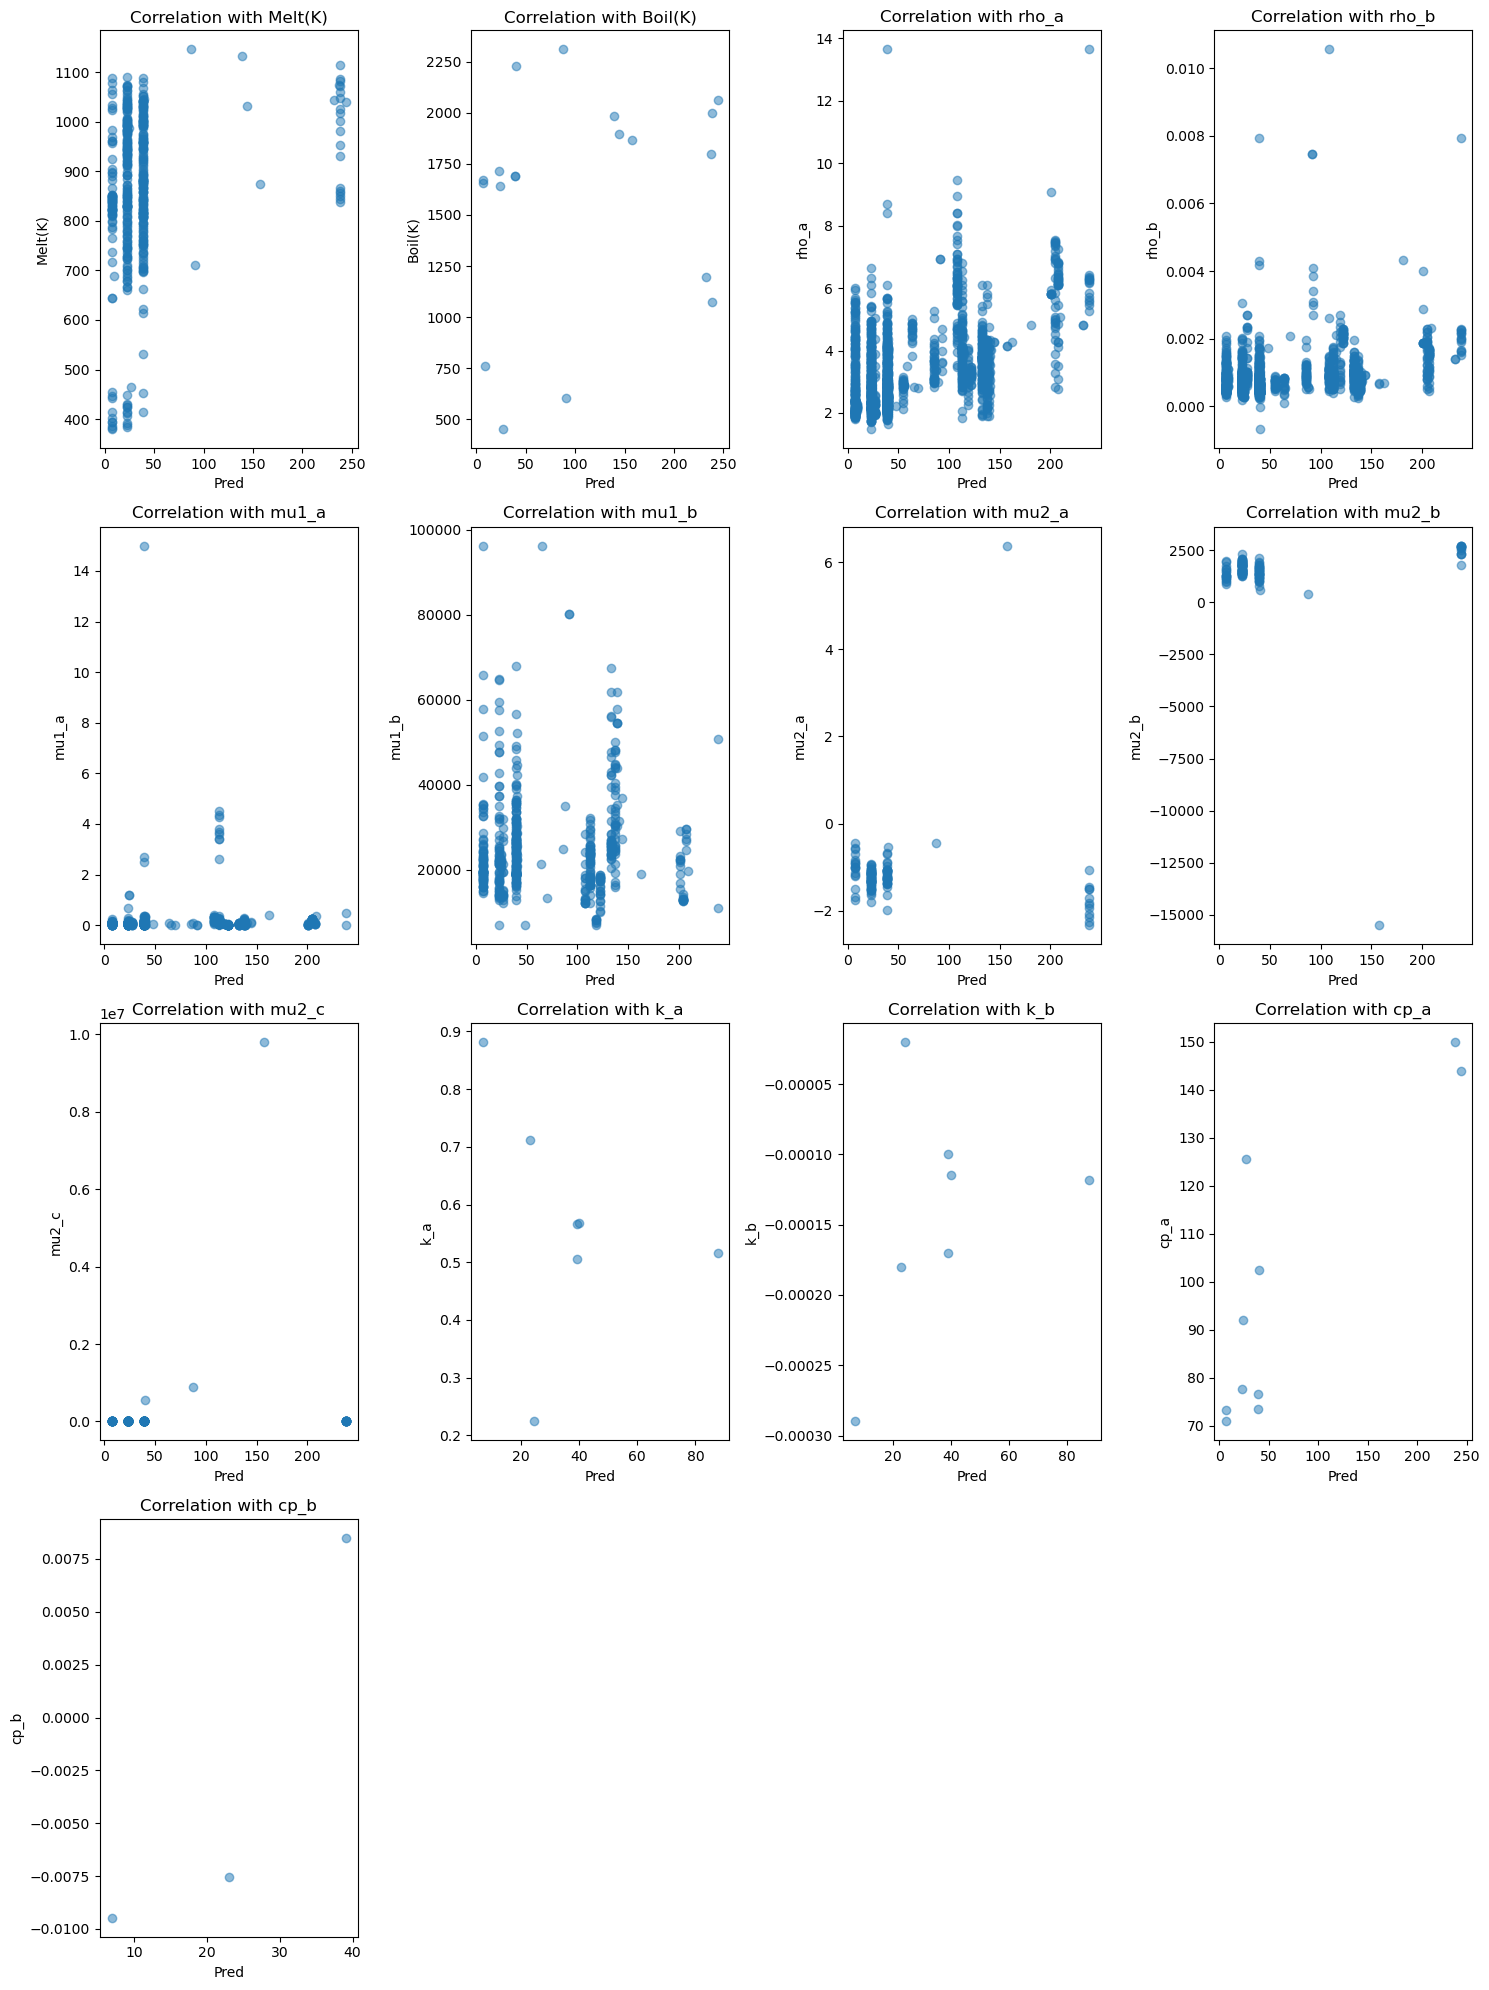

Correlation Table:
        Correlation
Melt(K)    0.219048
Boil(K)    0.174275
rho_a      0.531024
rho_b       0.32588
mu1_a      0.034361
mu1_b     -0.003768
mu2_a     -0.092765
mu2_b      0.033896
mu2_c      0.151279
k_a       -0.321733
k_b        0.374327
cp_a       0.845962
cp_b       0.911486


In [14]:
def safe_eval(x):
    try:
        value = ast.literal_eval(x)
        keys = value.keys()
        cats = [key for key in keys if key != 'Cl']
        return value[cats[0]]
    except Exception as e:
        print(f"Error evaluating {x}: {e}")
        return None

# Assuming 'data' is your DataFrame and 'data_cols' and 'pred_cols' are lists containing the relevant columns.
pred = data[data_cols[1]].apply(safe_eval)
tgt = data[pred_cols]

# Prepare the plotting grid
n_cols = 4
n_rows = (len(tgt.columns) + 1) // n_cols + 1

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

correlation_table = pd.DataFrame(index=tgt.columns, columns=['Correlation'])

for i, column in enumerate(tgt.columns):
    not_nan_indices = tgt[column].notna()
    filtered_pred = pred[not_nan_indices]
    filtered_tgt = tgt[column][not_nan_indices]

    axes[i].scatter(filtered_pred, filtered_tgt, alpha=0.5)
    axes[i].set_title(f'Correlation with {column}')
    axes[i].set_xlabel('Pred')
    axes[i].set_ylabel(column)

    # Calculate and store the correlation coefficient
    correlation_coefficient = filtered_pred.corr(filtered_tgt)
    correlation_table.loc[column] = correlation_coefficient

# Remove any unused subplots if tgt columns are fewer than the grid size
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Output the final correlation table
print("Correlation Table:")
print(correlation_table)

# Electronegativity

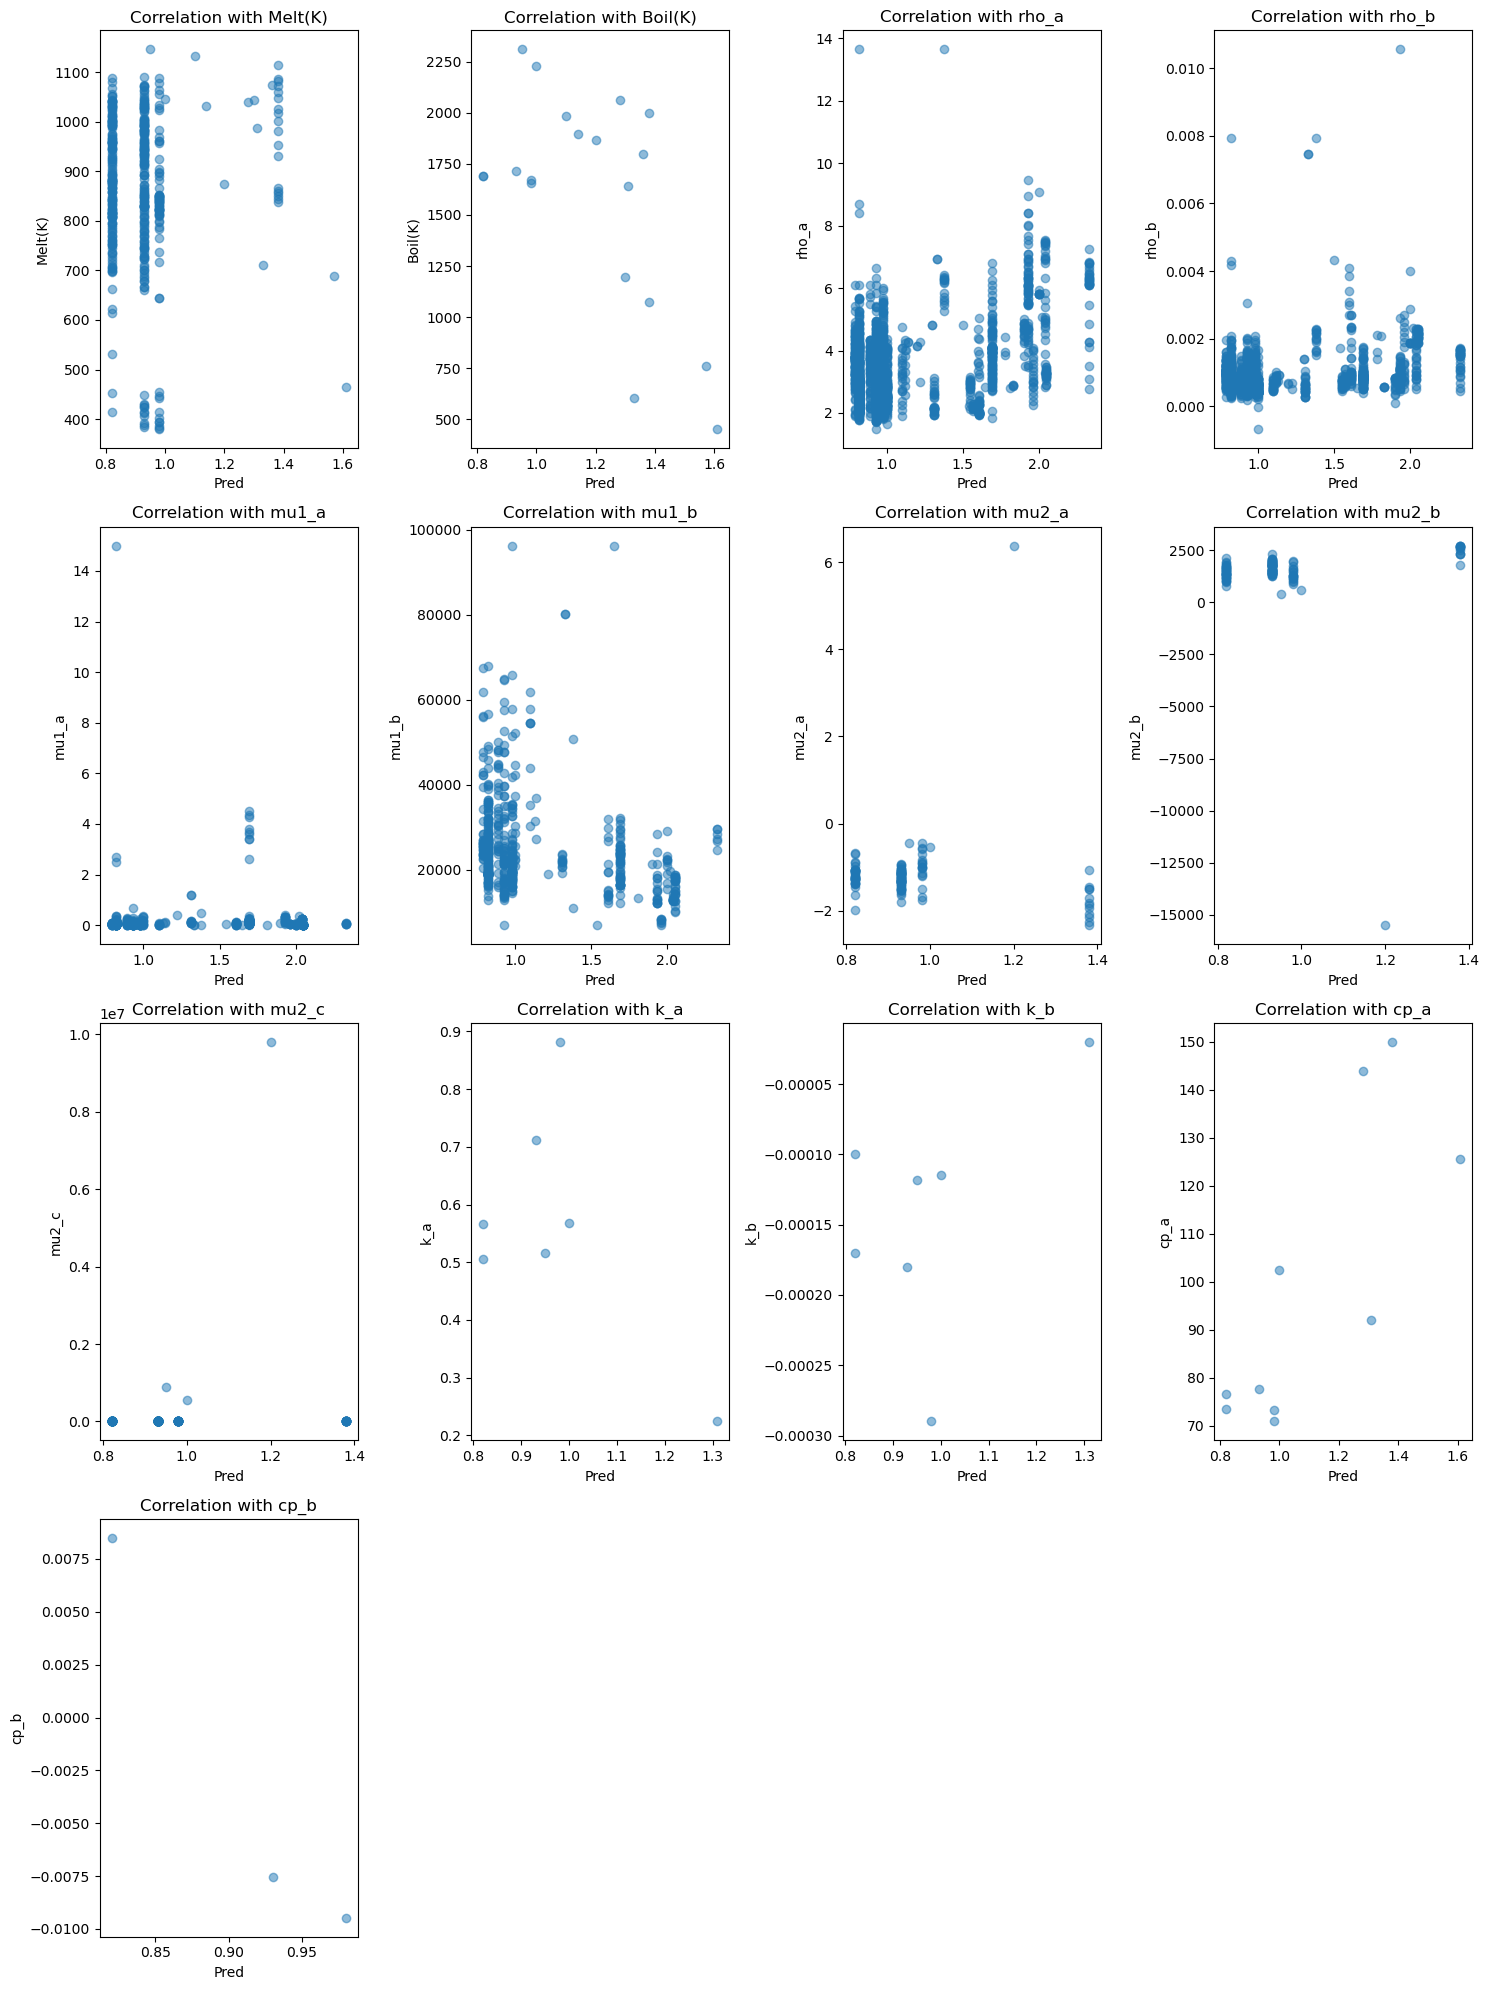

Correlation Table:
        Correlation
Melt(K)    0.022688
Boil(K)   -0.611557
rho_a      0.468239
rho_b      0.312857
mu1_a      0.062907
mu1_b     -0.310035
mu2_a     -0.071669
mu2_b       0.04342
mu2_c      0.141273
k_a       -0.544175
k_b        0.479101
cp_a       0.784554
cp_b      -0.977663


In [15]:
def safe_eval(x):
    try:
        value = ast.literal_eval(x)
        keys = value.keys()
        cats = [key for key in keys if key != 'Cl']
        return value[cats[0]]
    except Exception as e:
        print(f"Error evaluating {x}: {e}")
        return None

# Assuming 'data' is your DataFrame and 'data_cols' and 'pred_cols' are lists containing the relevant columns.
pred = data[data_cols[2]].apply(safe_eval)
tgt = data[pred_cols]

# Prepare the plotting grid
n_cols = 4
n_rows = (len(tgt.columns) + 1) // n_cols + 1

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

correlation_table = pd.DataFrame(index=tgt.columns, columns=['Correlation'])

for i, column in enumerate(tgt.columns):
    not_nan_indices = tgt[column].notna()
    filtered_pred = pred[not_nan_indices]
    filtered_tgt = tgt[column][not_nan_indices]

    axes[i].scatter(filtered_pred, filtered_tgt, alpha=0.5)
    axes[i].set_title(f'Correlation with {column}')
    axes[i].set_xlabel('Pred')
    axes[i].set_ylabel(column)

    # Calculate and store the correlation coefficient
    correlation_coefficient = filtered_pred.corr(filtered_tgt)
    correlation_table.loc[column] = correlation_coefficient

# Remove any unused subplots if tgt columns are fewer than the grid size
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Output the final correlation table
print("Correlation Table:")
print(correlation_table)

# Ionic Charge - Not used

{'Al': '3+', 'Cl': '1-'}   ['Al']   3
{'Be': '2+', 'Cl': '1-'}   ['Be']   2
{'Ca': '2+', 'Cl': '1-'}   ['Ca']   2
{'Gd': '3+', 'Cl': '1-'}   ['Gd']   3
{'K': '1+', 'Cl': '1-'}   ['K']   1
{'La': '3+', 'Cl': '1-'}   ['La']   3
{'Li': '1+', 'Cl': '1-'}   ['Li']   1
{'Mg': '2+', 'Cl': '1-'}   ['Mg']   2
{'Na': '1+', 'Cl': '1-'}   ['Na']   1
{'Nd': '3+, 4+', 'Cl': '1-'}   ['Nd']   34
{'Np': '5+', 'Cl': '1-'}   ['Np']   5
{'Pu': '4+', 'Cl': '1-'}   ['Pu']   4
{'Sr': '2+', 'Cl': '1-'}   ['Sr']   2
{'Th': '4+', 'Cl': '1-'}   ['Th']   4
{'U': '3+, 4+, 6+', 'Cl': '1-'}   ['U']   346
{'U': '3+, 4+, 6+', 'Cl': '1-'}   ['U']   346
{'Zr': '4+', 'Cl': '1-'}   ['Zr']   4
{'K': '1+', 'Cl': '1-', 'Al': '3+'}   ['K', 'Al']   1
{'K': '1+', 'Cl': '1-', 'Al': '3+'}   ['K', 'Al']   1
{'K': '1+', 'Cl': '1-', 'Al': '3+'}   ['K', 'Al']   1
{'K': '1+', 'Cl': '1-', 'Al': '3+'}   ['K', 'Al']   1
{'K': '1+', 'Cl': '1-', 'Al': '3+'}   ['K', 'Al']   1
{'K': '1+', 'Cl': '1-', 'Al': '3+'}   ['K', 'Al']   1
{'K': '1+',

/Users/krymmd/anaconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/krymmd/anaconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


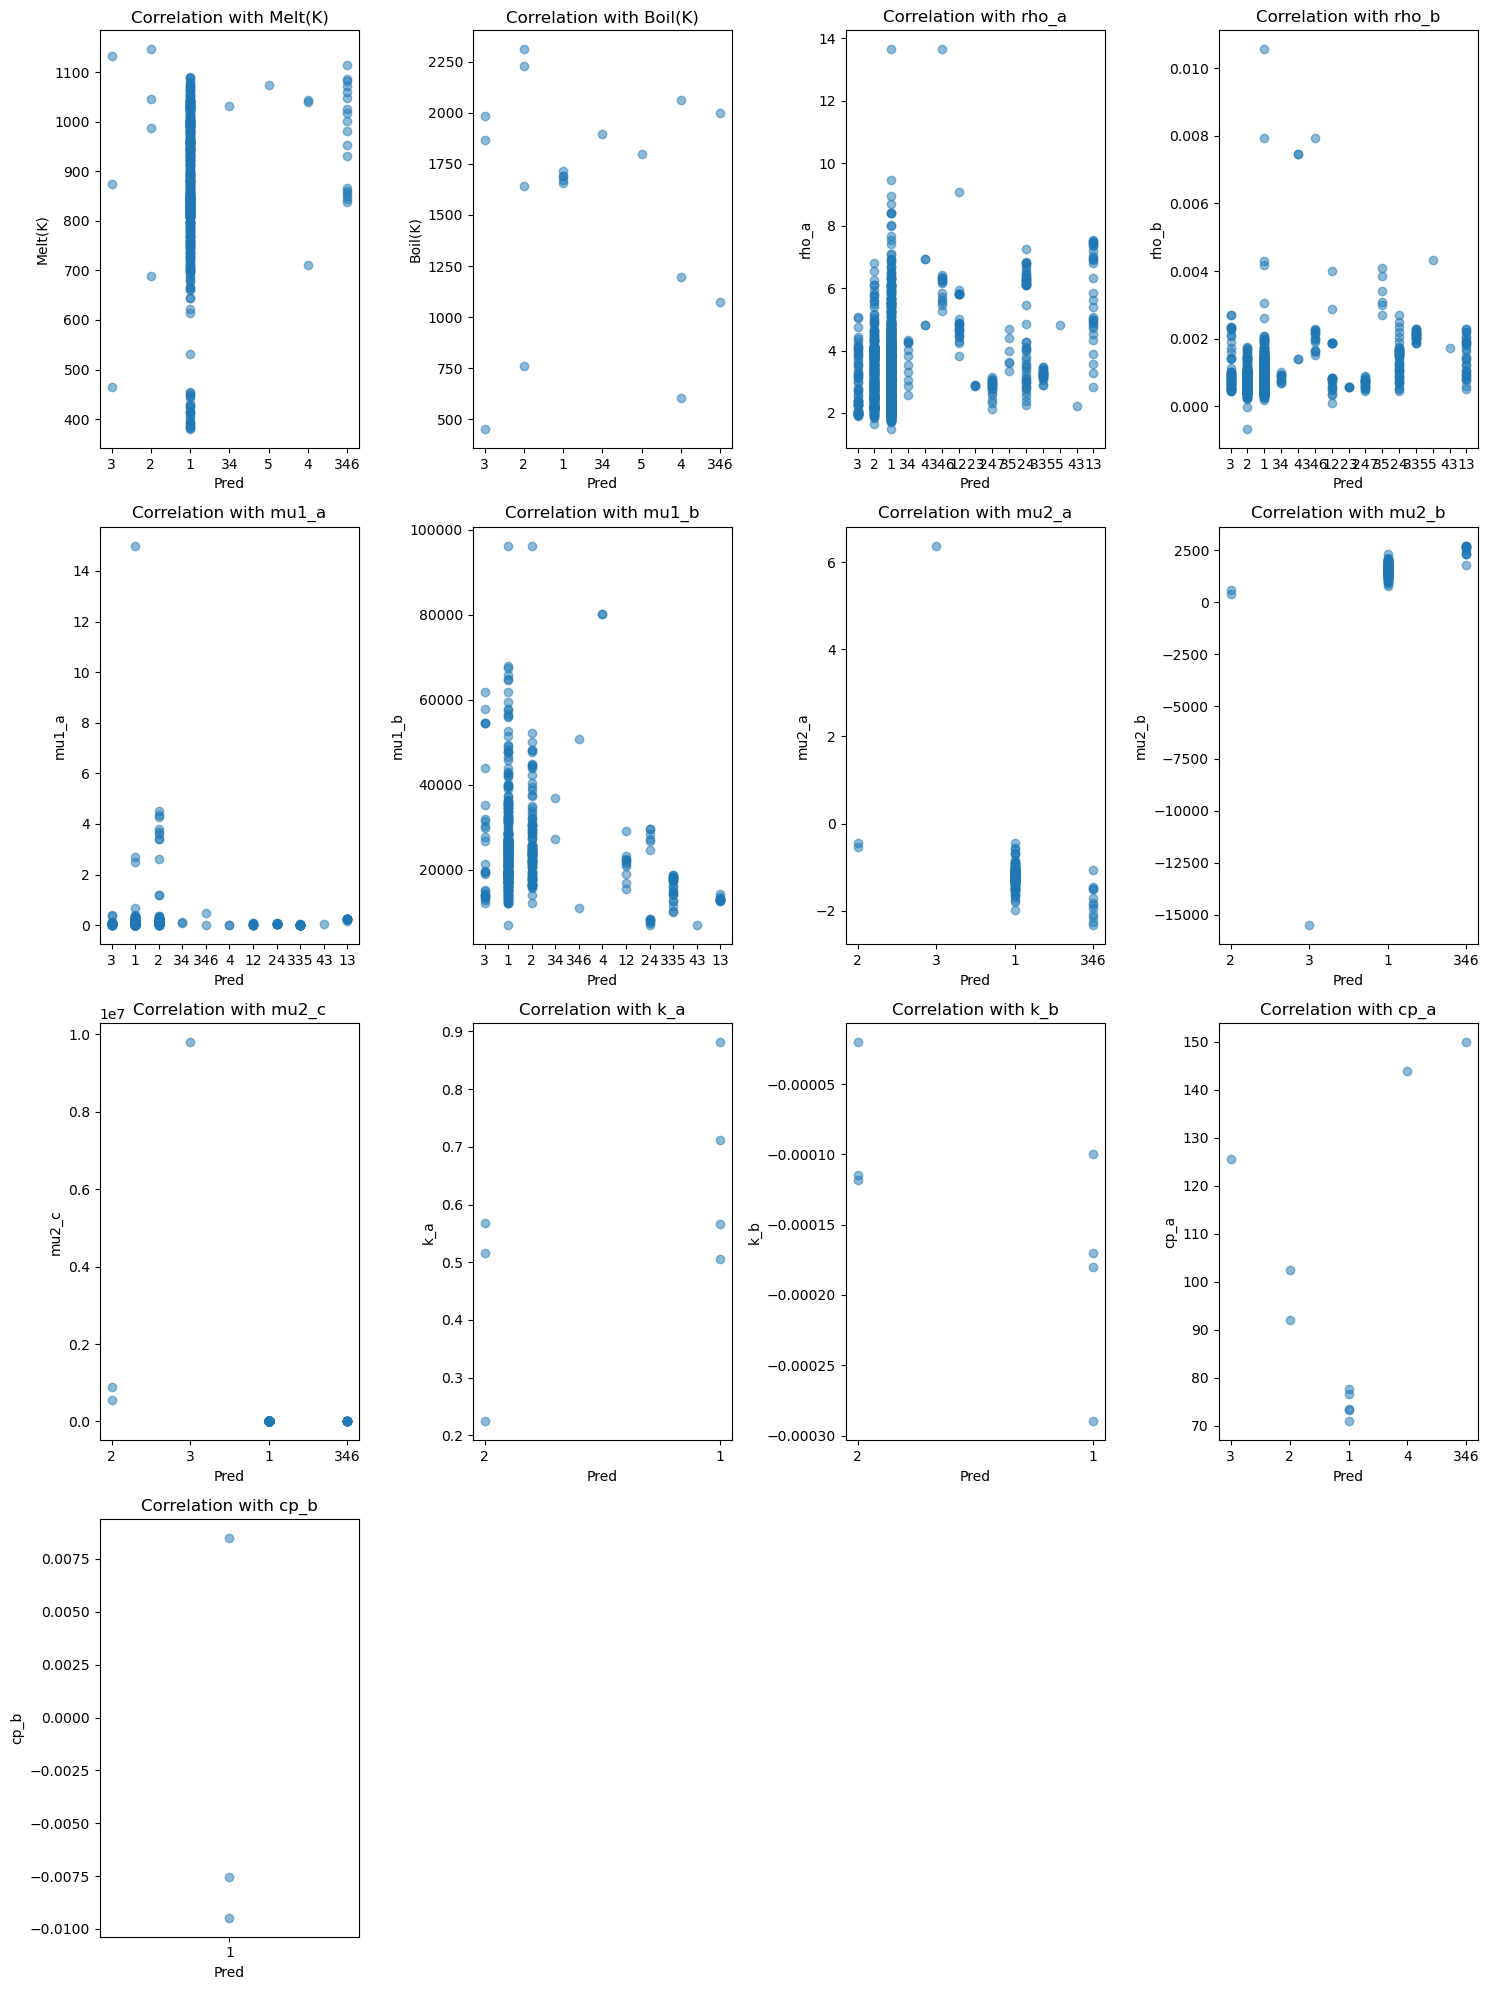

Correlation Table:
        Correlation
Melt(K)    0.140338
Boil(K)   -0.030755
rho_a      0.116512
rho_b      0.289688
mu1_a     -0.046168
mu1_b     -0.167267
mu2_a     -0.262607
mu2_b      0.213207
mu2_c     -0.030126
k_a       -0.609875
k_b        0.642487
cp_a         0.5972
cp_b            NaN


In [16]:
def safe_eval(x):
    try:
        value = ast.literal_eval(x)
        keys = value.keys()
        cats = [key for key in keys if key != 'Cl']
        print(value, ' ', cats, ' ', re.sub(r'[^0-9.]', '', value[cats[0]]))
        return re.sub(r'[^0-9.]', '', value[cats[0]])
    except Exception as e:
        print(f"Error evaluating {x}: {e}")
        return None

# Assuming 'data' is your DataFrame and 'data_cols' and 'pred_cols' are lists containing the relevant columns.
pred = data[data_cols[3]].apply(safe_eval)
tgt = data[pred_cols]

# Prepare the plotting grid
n_cols = 4
n_rows = (len(tgt.columns) + 1) // n_cols + 1

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

correlation_table = pd.DataFrame(index=tgt.columns, columns=['Correlation'])

for i, column in enumerate(tgt.columns):
    not_nan_indices = tgt[column].notna()
    filtered_pred = pred[not_nan_indices]
    filtered_tgt = tgt[column][not_nan_indices]

    axes[i].scatter(filtered_pred, filtered_tgt, alpha=0.5)
    axes[i].set_title(f'Correlation with {column}')
    axes[i].set_xlabel('Pred')
    axes[i].set_ylabel(column)

    # Calculate and store the correlation coefficient
    correlation_coefficient = filtered_pred.corr(filtered_tgt)
    correlation_table.loc[column] = correlation_coefficient

# Remove any unused subplots if tgt columns are fewer than the grid size
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Output the final correlation table
print("Correlation Table:")
print(correlation_table)

# Atomic Radius

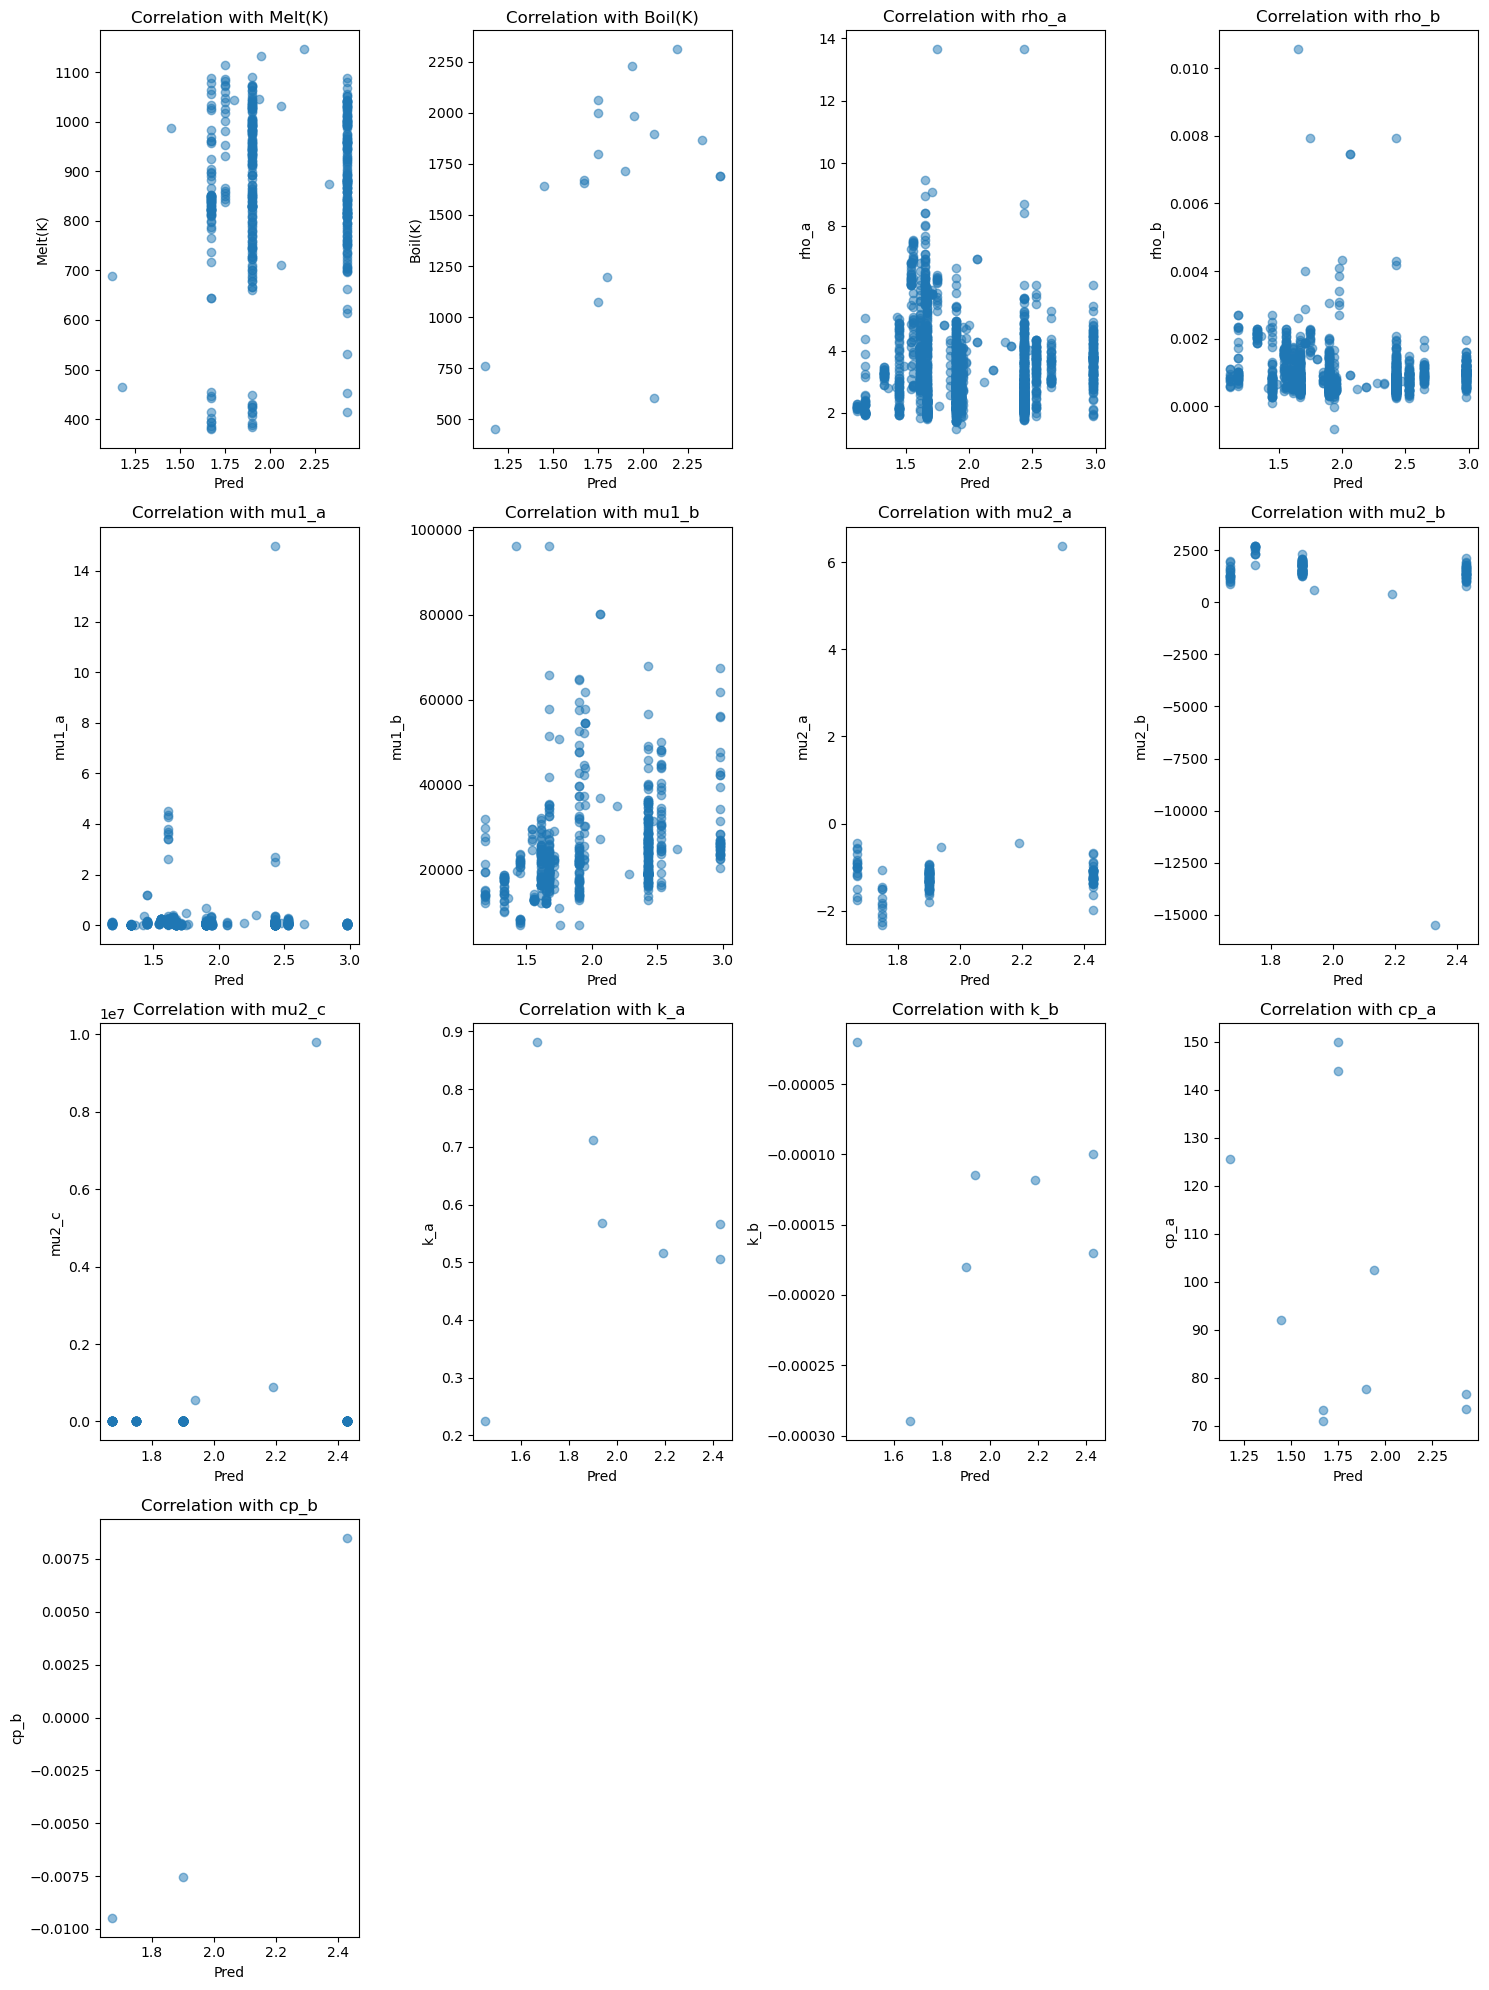

Correlation Table:
        Correlation
Melt(K)    0.124805
Boil(K)    0.498277
rho_a     -0.134014
rho_b     -0.126683
mu1_a     -0.034804
mu1_b      0.297488
mu2_a      0.138261
mu2_b     -0.179544
mu2_c      0.102472
k_a        0.074025
k_b        -0.02942
cp_a      -0.404892
cp_b       0.979888


In [17]:
def safe_eval(x):
    try:
        value = ast.literal_eval(x)
        keys = value.keys()
        cats = [key for key in keys if key != 'Cl']
        return value[cats[0]]
    except Exception as e:
        print(f"Error evaluating {x}: {e}")
        return None

# Assuming 'data' is your DataFrame and 'data_cols' and 'pred_cols' are lists containing the relevant columns.
pred = data[data_cols[4]].apply(safe_eval)
tgt = data[pred_cols]

# Prepare the plotting grid
n_cols = 4
n_rows = (len(tgt.columns) + 1) // n_cols + 1

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

correlation_table = pd.DataFrame(index=tgt.columns, columns=['Correlation'])

for i, column in enumerate(tgt.columns):
    not_nan_indices = tgt[column].notna()
    filtered_pred = pred[not_nan_indices]
    filtered_tgt = tgt[column][not_nan_indices]

    axes[i].scatter(filtered_pred, filtered_tgt, alpha=0.5)
    axes[i].set_title(f'Correlation with {column}')
    axes[i].set_xlabel('Pred')
    axes[i].set_ylabel(column)

    # Calculate and store the correlation coefficient
    correlation_coefficient = filtered_pred.corr(filtered_tgt)
    correlation_table.loc[column] = correlation_coefficient

# Remove any unused subplots if tgt columns are fewer than the grid size
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Output the final correlation table
print("Correlation Table:")
print(correlation_table)

# Ionic_radius_element[Angstrom]

In [18]:
data[data_cols[5]]

0       {'Al': 1.25, 'Cl': 1.0}
1       {'Be': 1.05, 'Cl': 1.0}
3        {'Ca': 1.8, 'Cl': 1.0}
5        {'Gd': 1.8, 'Cl': 1.0}
7         {'K': 2.2, 'Cl': 1.0}
                 ...           
4865     {'U': 1.75, 'Cl': 1.0}
4866     {'U': 1.75, 'Cl': 1.0}
4869     {'Y': 1.85, 'Cl': 1.0}
4872    {'Zn': 1.35, 'Cl': 1.0}
4875    {'Zr': 1.55, 'Cl': 1.0}
Name: ionic_radius_element[Angstrom], Length: 2155, dtype: object

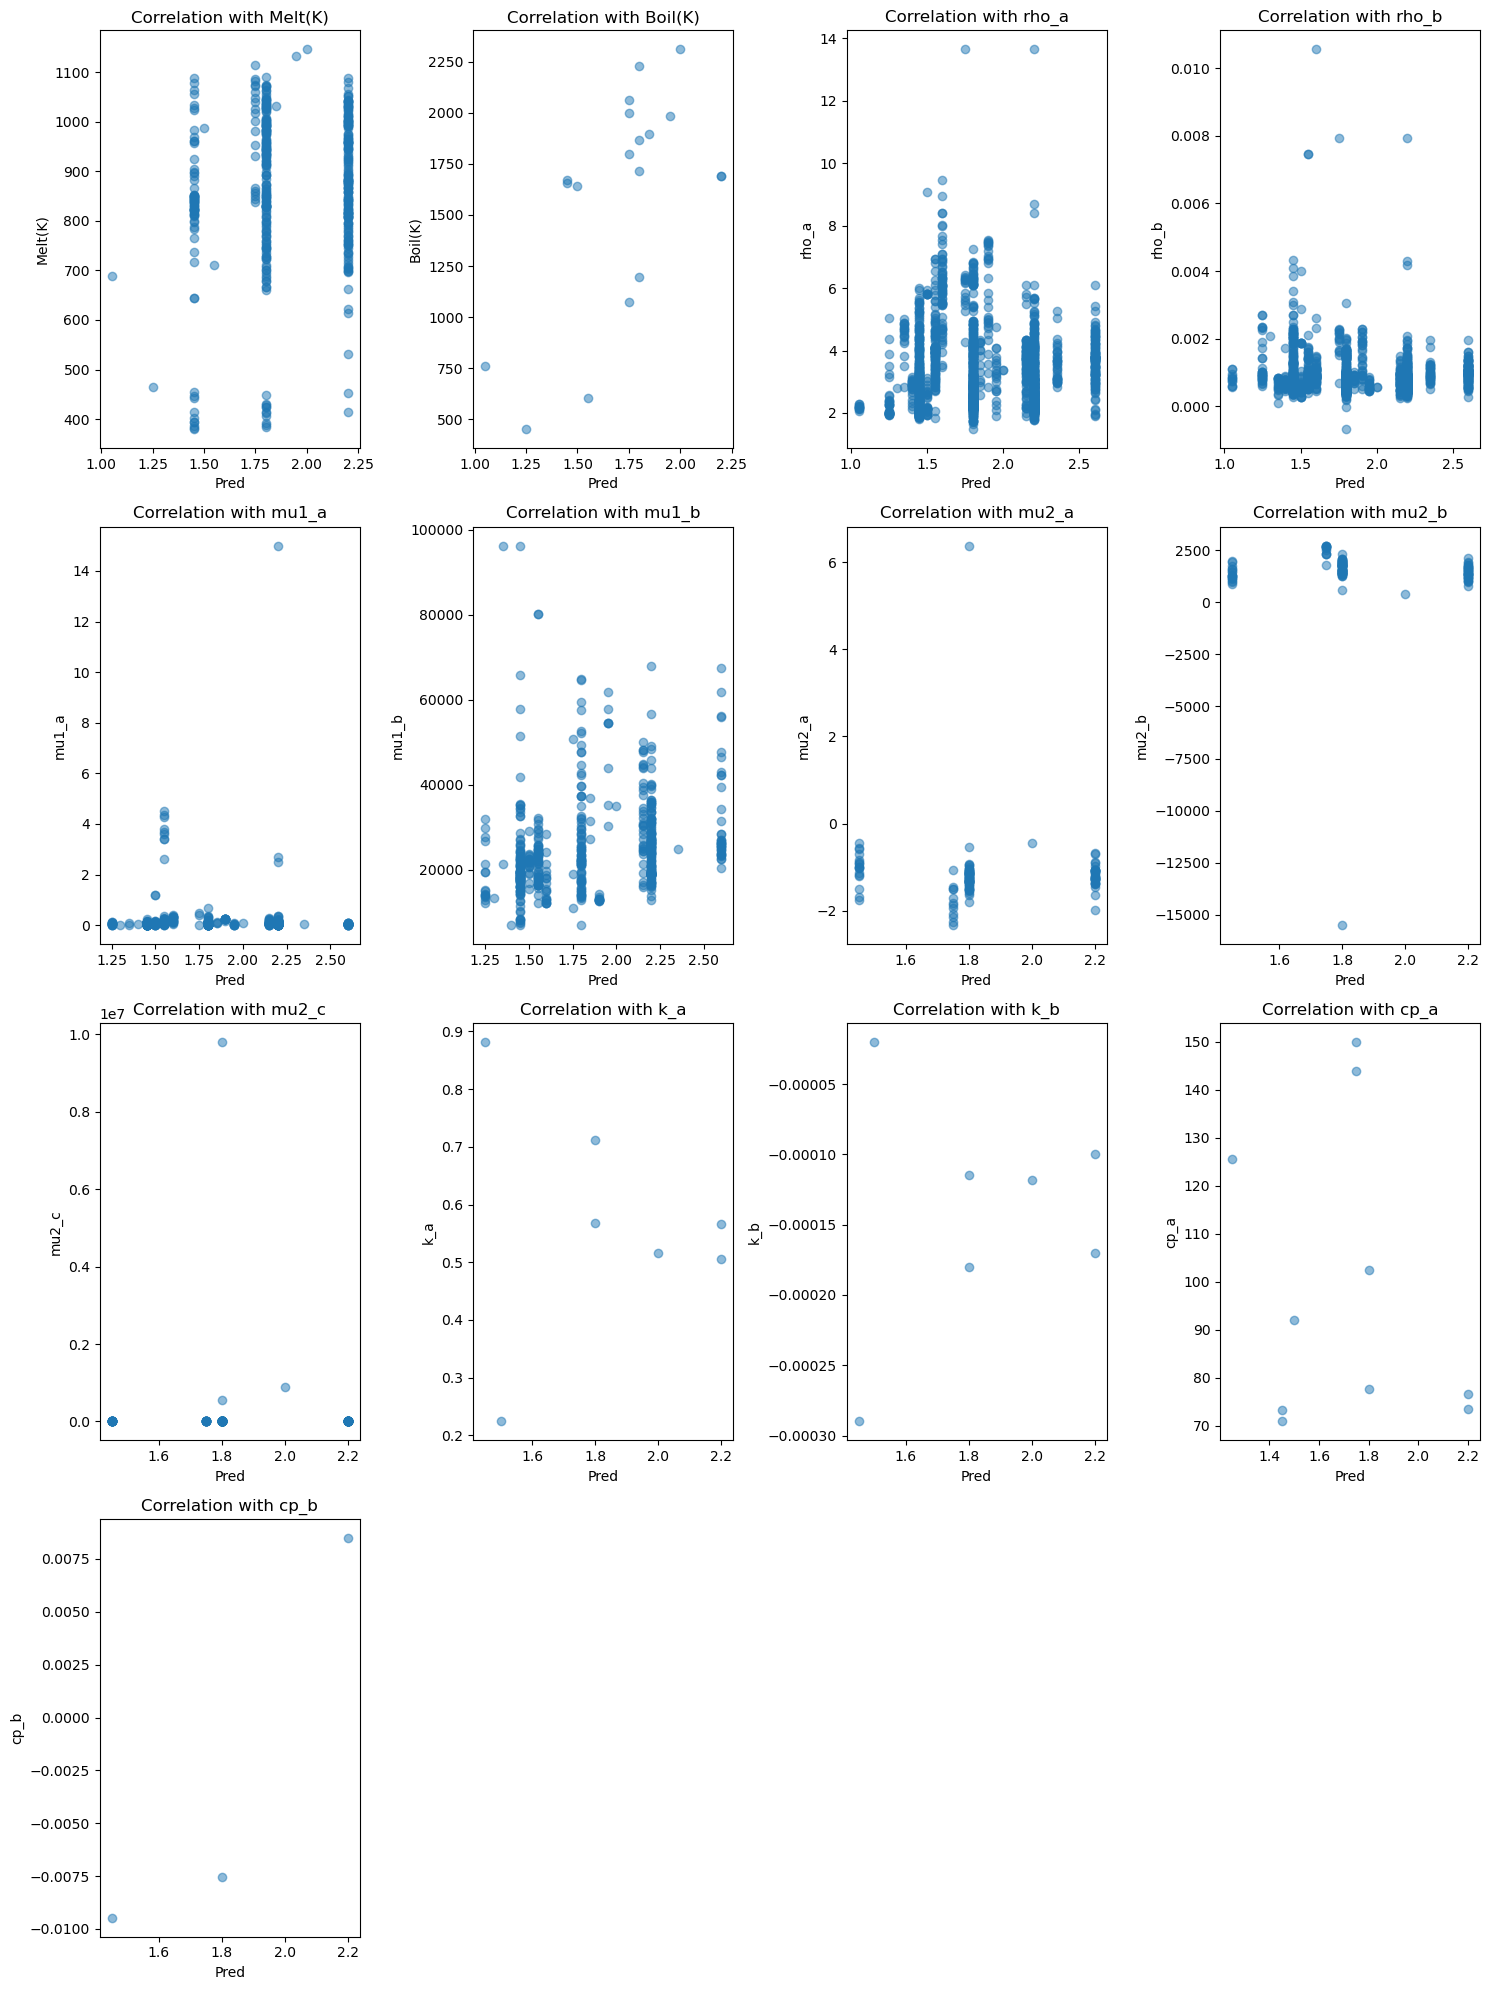

Correlation Table:
        Correlation
Melt(K)    0.165154
Boil(K)     0.60895
rho_a     -0.065685
rho_b     -0.107056
mu1_a      -0.02699
mu1_b      0.249669
mu2_a     -0.027026
mu2_b      -0.01959
mu2_c     -0.019005
k_a       -0.116632
k_b        0.167179
cp_a      -0.206451
cp_b       0.926233


In [19]:
def safe_eval(x):
    try:
        value = ast.literal_eval(x)
        keys = value.keys()
        cats = [key for key in keys if key != 'Cl']
        return value[cats[0]]
    except Exception as e:
        print(f"Error evaluating {x}: {e}")
        return None

# Assuming 'data' is your DataFrame and 'data_cols' and 'pred_cols' are lists containing the relevant columns.
pred = data[data_cols[5]].apply(safe_eval)
tgt = data[pred_cols]

# Prepare the plotting grid
n_cols = 4
n_rows = (len(tgt.columns) + 1) // n_cols + 1

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

correlation_table = pd.DataFrame(index=tgt.columns, columns=['Correlation'])

for i, column in enumerate(tgt.columns):
    not_nan_indices = tgt[column].notna()
    filtered_pred = pred[not_nan_indices]
    filtered_tgt = tgt[column][not_nan_indices]

    axes[i].scatter(filtered_pred, filtered_tgt, alpha=0.5)
    axes[i].set_title(f'Correlation with {column}')
    axes[i].set_xlabel('Pred')
    axes[i].set_ylabel(column)

    # Calculate and store the correlation coefficient
    correlation_coefficient = filtered_pred.corr(filtered_tgt)
    correlation_table.loc[column] = correlation_coefficient

# Remove any unused subplots if tgt columns are fewer than the grid size
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Output the final correlation table
print("Correlation Table:")
print(correlation_table)

# covalent_radius_element[Angstrom] - Drop because of NaNs

In [20]:
data[data_cols[6]]

0       {'Al': 1.18, 'Cl': 0.99}
1        {'Be': 0.9, 'Cl': 0.99}
3       {'Ca': 1.74, 'Cl': 0.99}
5        {'Gd': nan, 'Cl': 0.99}
7        {'K': 1.96, 'Cl': 0.99}
                  ...           
4865      {'U': nan, 'Cl': 0.99}
4866      {'U': nan, 'Cl': 0.99}
4869     {'Y': 1.62, 'Cl': 0.99}
4872    {'Zn': 1.31, 'Cl': 0.99}
4875    {'Zr': 1.48, 'Cl': 0.99}
Name: covalent_radius_element[Angstrom], Length: 2155, dtype: object

# First ionization energy

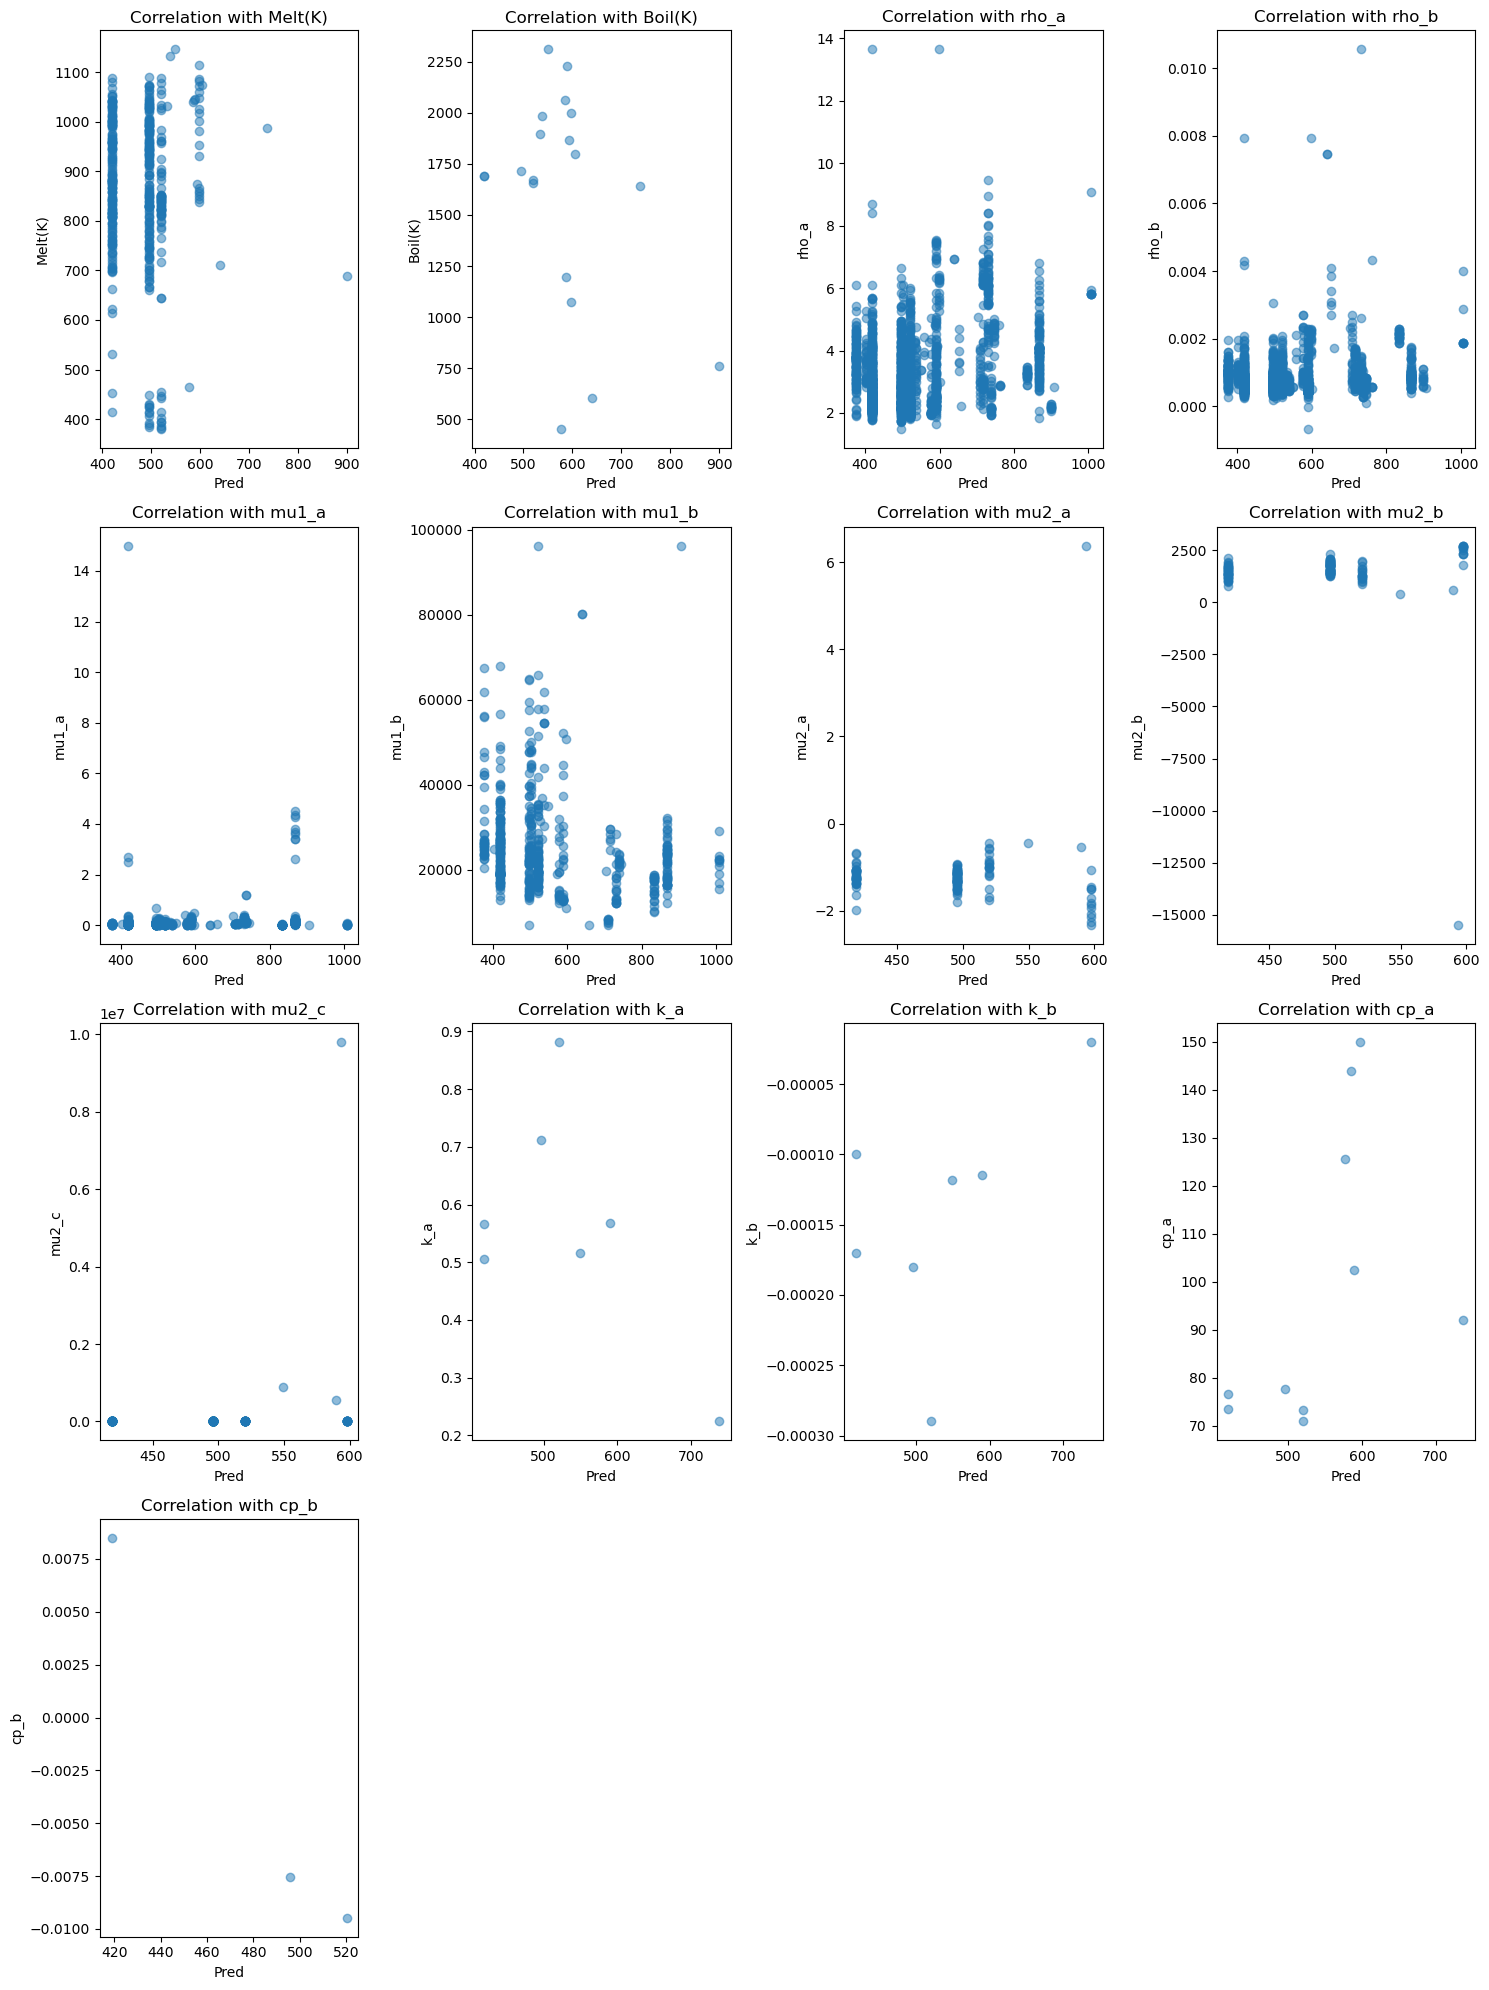

Correlation Table:
        Correlation
Melt(K)   -0.034633
Boil(K)   -0.397454
rho_a       0.30632
rho_b      0.193854
mu1_a      0.105786
mu1_b     -0.224261
mu2_a      0.034586
mu2_b     -0.030515
mu2_c      0.185632
k_a       -0.548178
k_b          0.5161
cp_a        0.48325
cp_b      -0.991038


In [21]:
def safe_eval(x):
    try:
        value = ast.literal_eval(x)
        keys = value.keys()
        cats = [key for key in keys if key != 'Cl']
        return value[cats[0]]
    except Exception as e:
        print(f"Error evaluating {x}: {e}")
        return None

# Assuming 'data' is your DataFrame and 'data_cols' and 'pred_cols' are lists containing the relevant columns.
pred = data[data_cols[7]].apply(safe_eval)
tgt = data[pred_cols]

# Prepare the plotting grid
n_cols = 4
n_rows = (len(tgt.columns) + 1) // n_cols + 1

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

correlation_table = pd.DataFrame(index=tgt.columns, columns=['Correlation'])

for i, column in enumerate(tgt.columns):
    not_nan_indices = tgt[column].notna()
    filtered_pred = pred[not_nan_indices]
    filtered_tgt = tgt[column][not_nan_indices]

    axes[i].scatter(filtered_pred, filtered_tgt, alpha=0.5)
    axes[i].set_title(f'Correlation with {column}')
    axes[i].set_xlabel('Pred')
    axes[i].set_ylabel(column)

    # Calculate and store the correlation coefficient
    correlation_coefficient = filtered_pred.corr(filtered_tgt)
    correlation_table.loc[column] = correlation_coefficient

# Remove any unused subplots if tgt columns are fewer than the grid size
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Output the final correlation table
print("Correlation Table:")
print(correlation_table)

# First data models

In [59]:
def safe_eval(x):
    try:
        value = ast.literal_eval(x)
        keys = value.keys()
        cats = [key for key in keys if key != 'Cl']
        return value[cats[0]]
    except Exception as e:
        print(f"Error evaluating {x}: {e}")
        return None
    
selected_predictors = [5] #[0, 1, 2, 4, 5, 7]
pred = data[data_cols[selected_predictors]]
for col in pred.columns:
    pred[col] = pred[col].apply(safe_eval)

pred

/var/folders/z1/wqr4m7_s1_q662sg5g3ckn7dw7kz0k/T/ipykernel_35789/771838720.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pred[col] = pred[col].apply(safe_eval)


,ionic_radius_element[Angstrom]
0,1.25
1,1.05
3,1.80
5,1.80
7,2.20
...,...
4865,1.75
4866,1.75
4869,1.85
4872,1.35


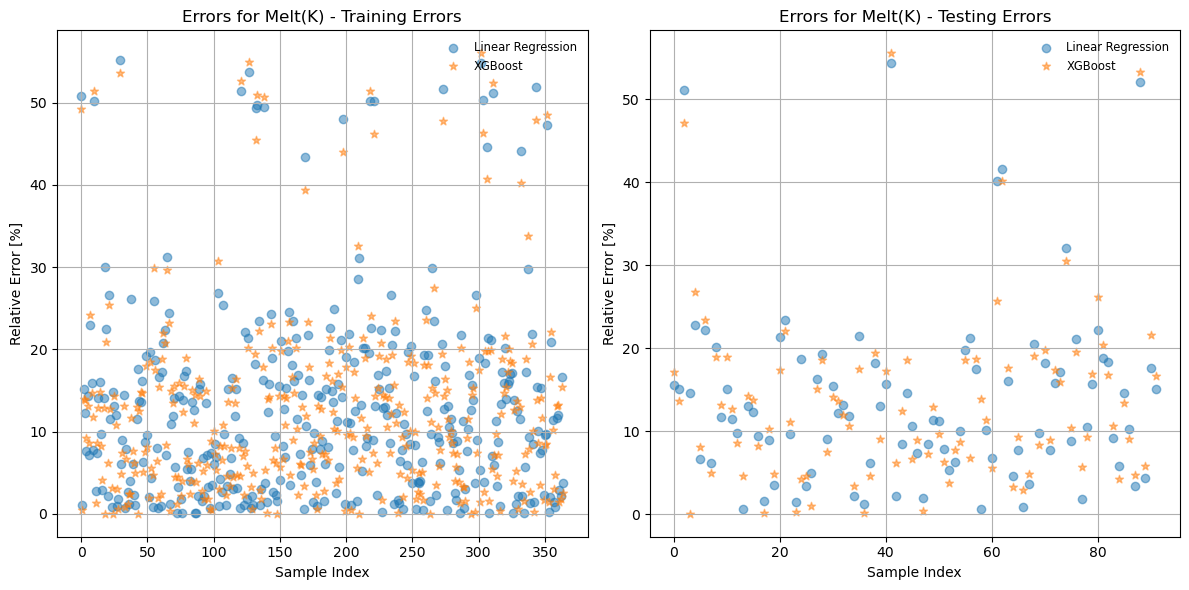

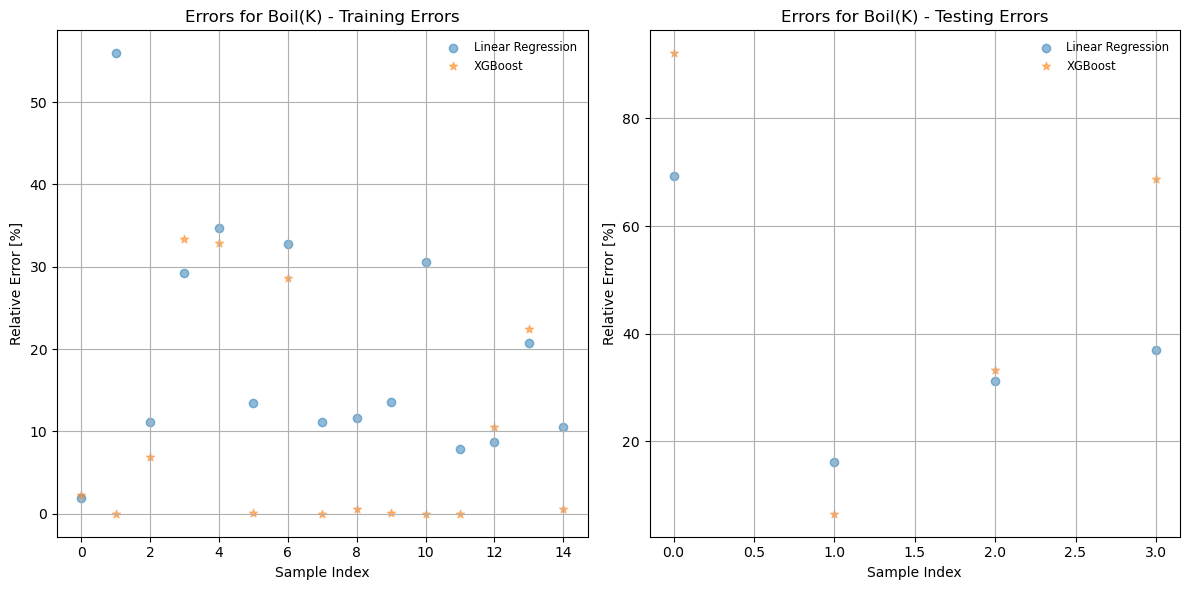

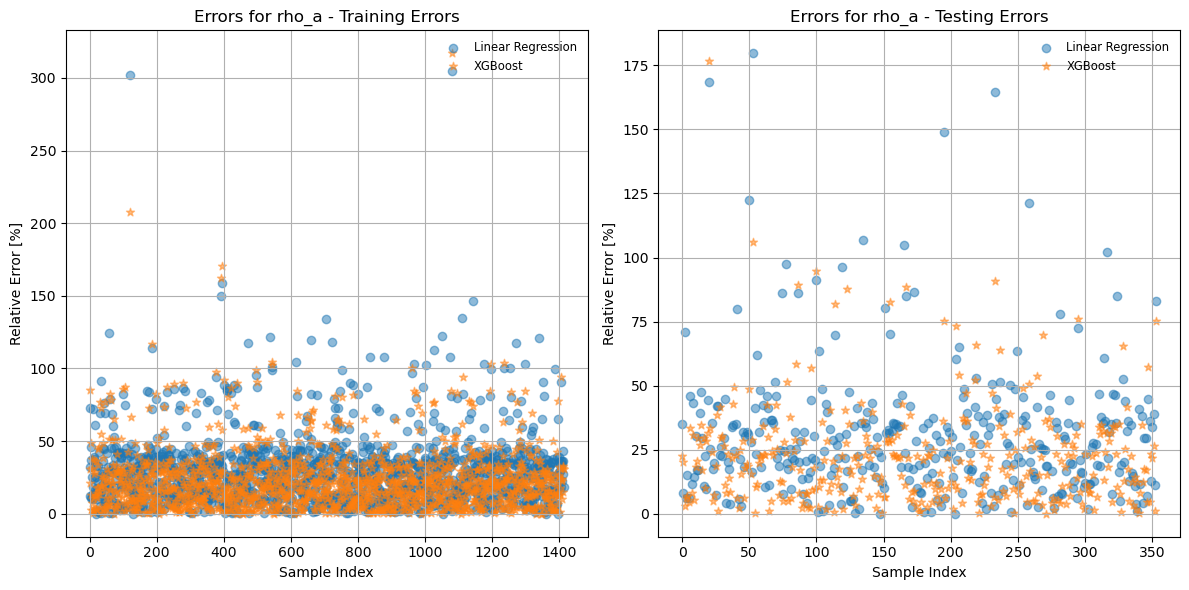

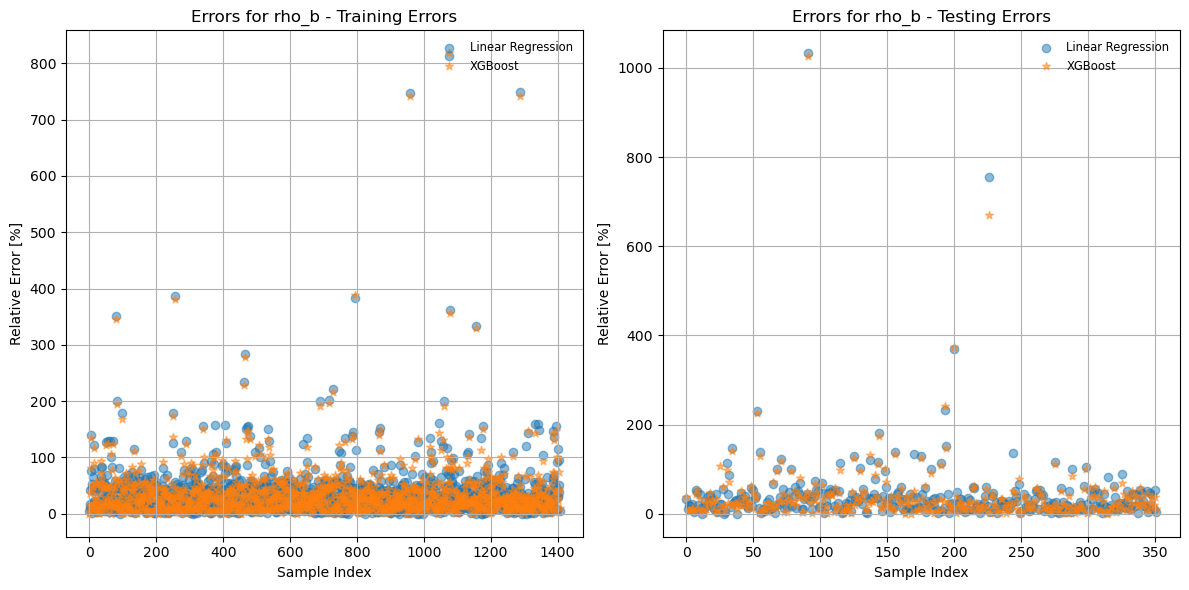

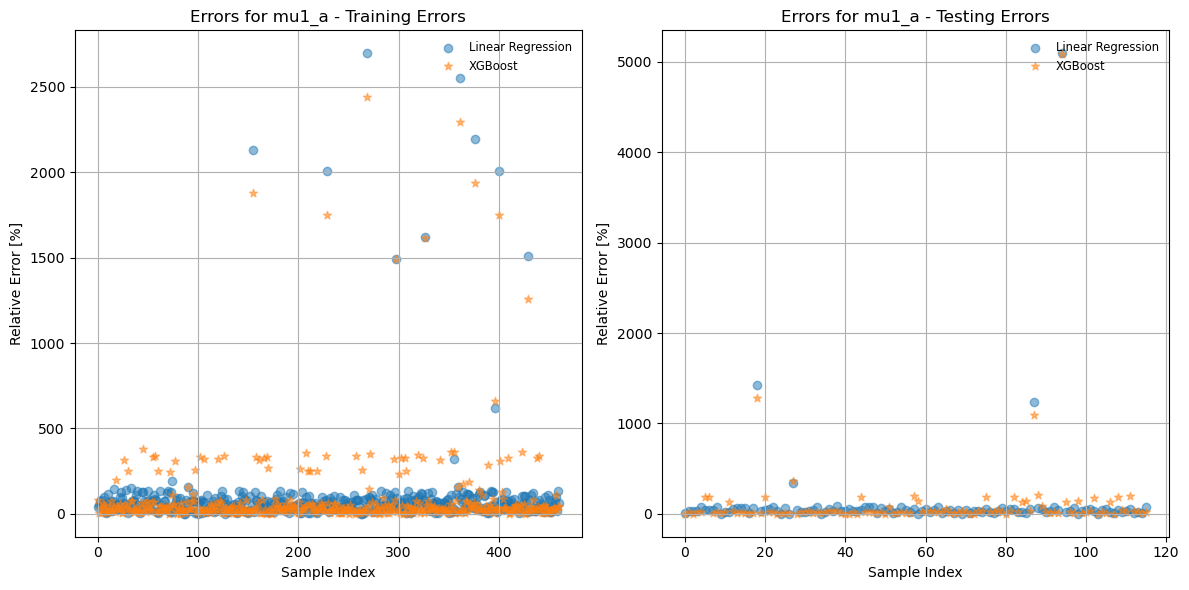

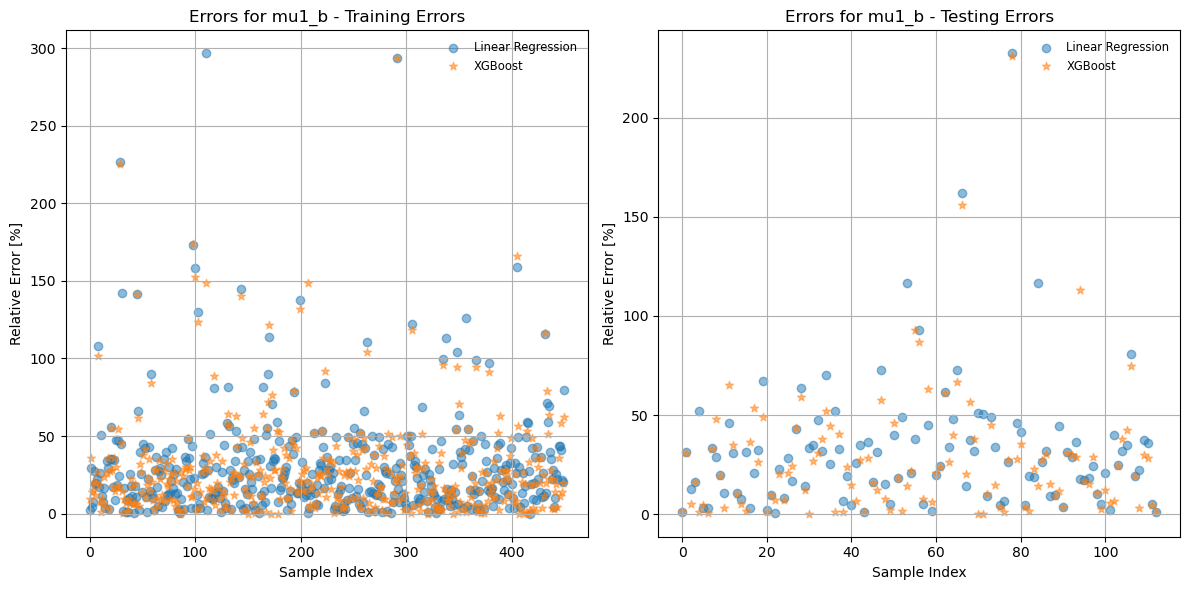

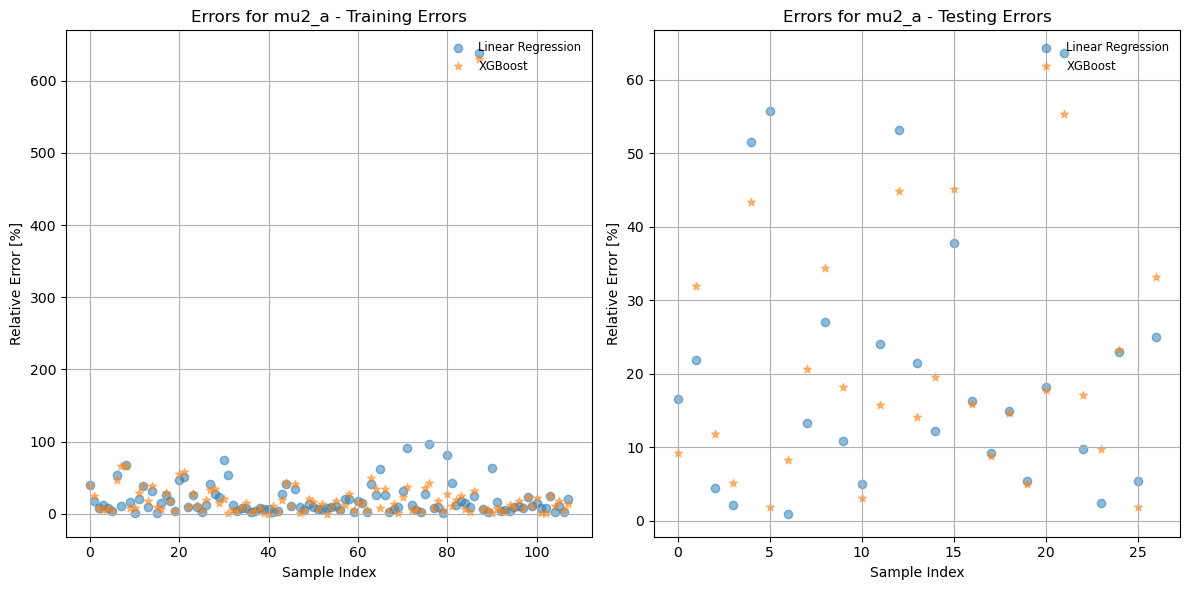

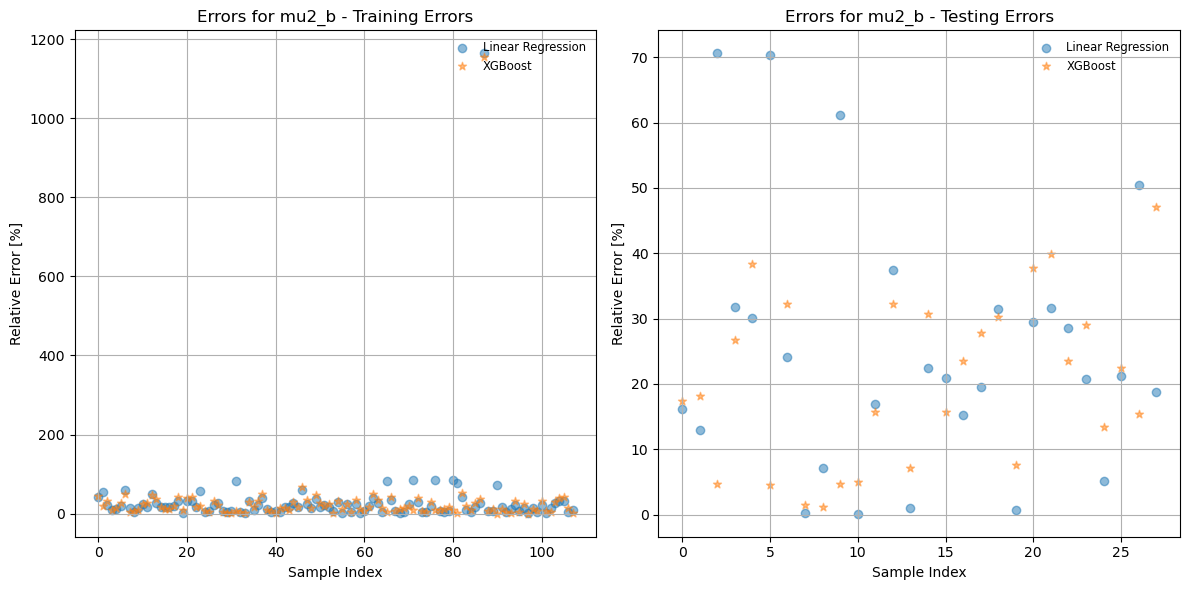

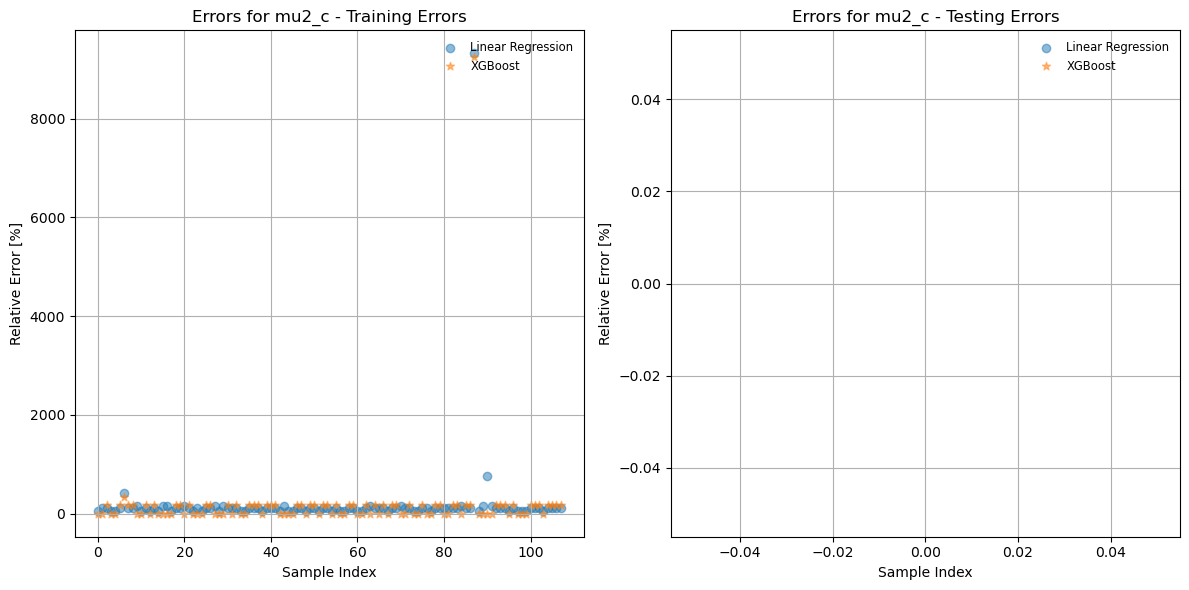

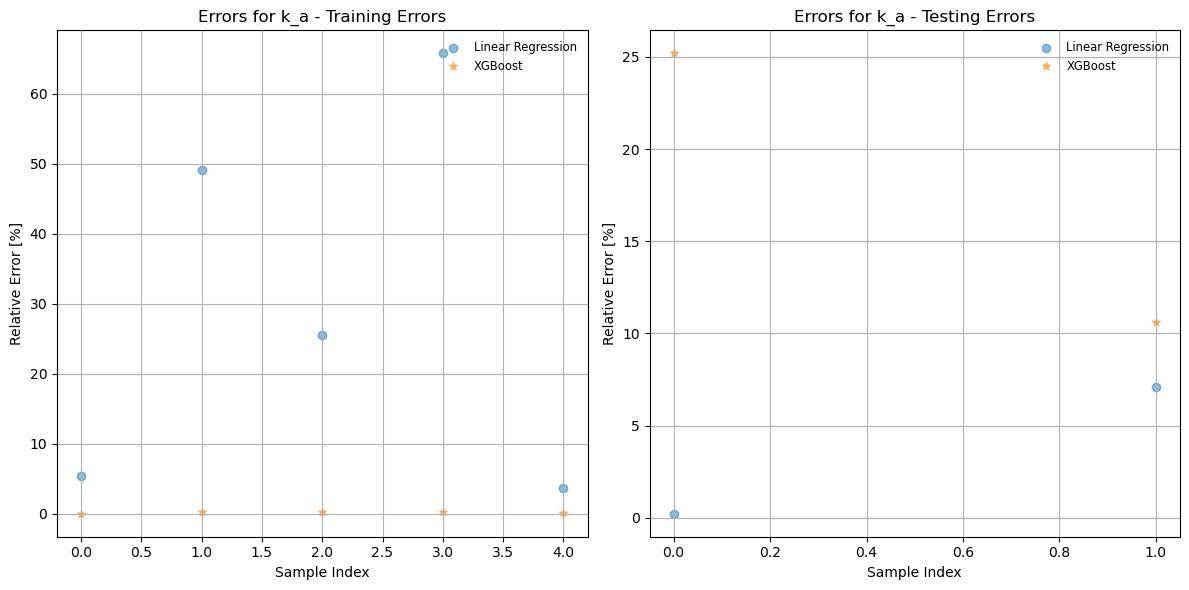

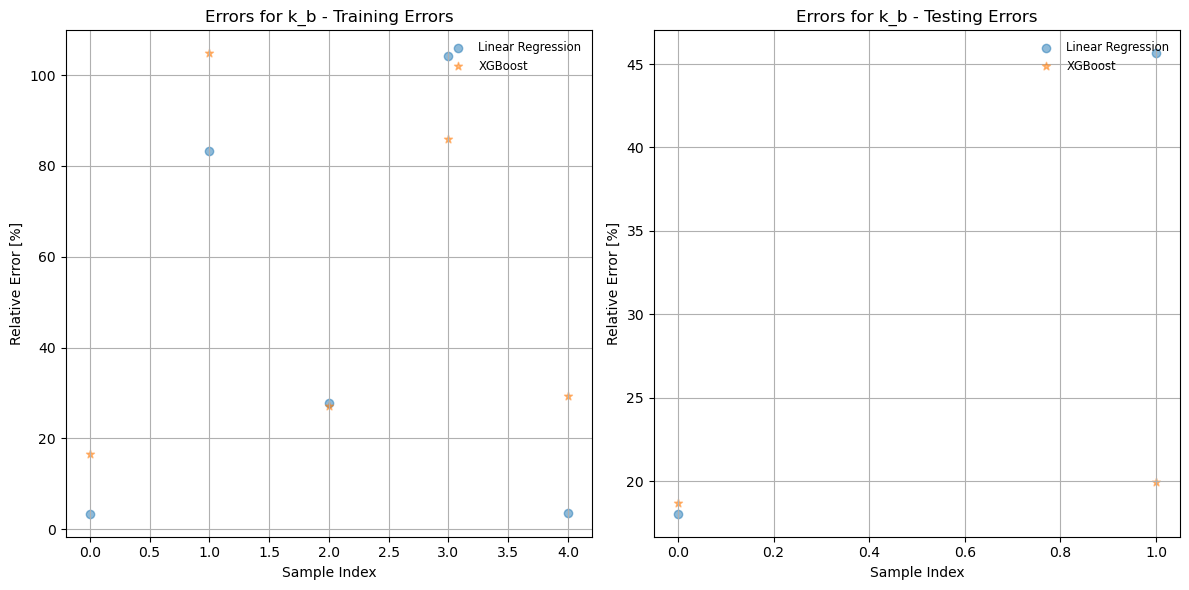

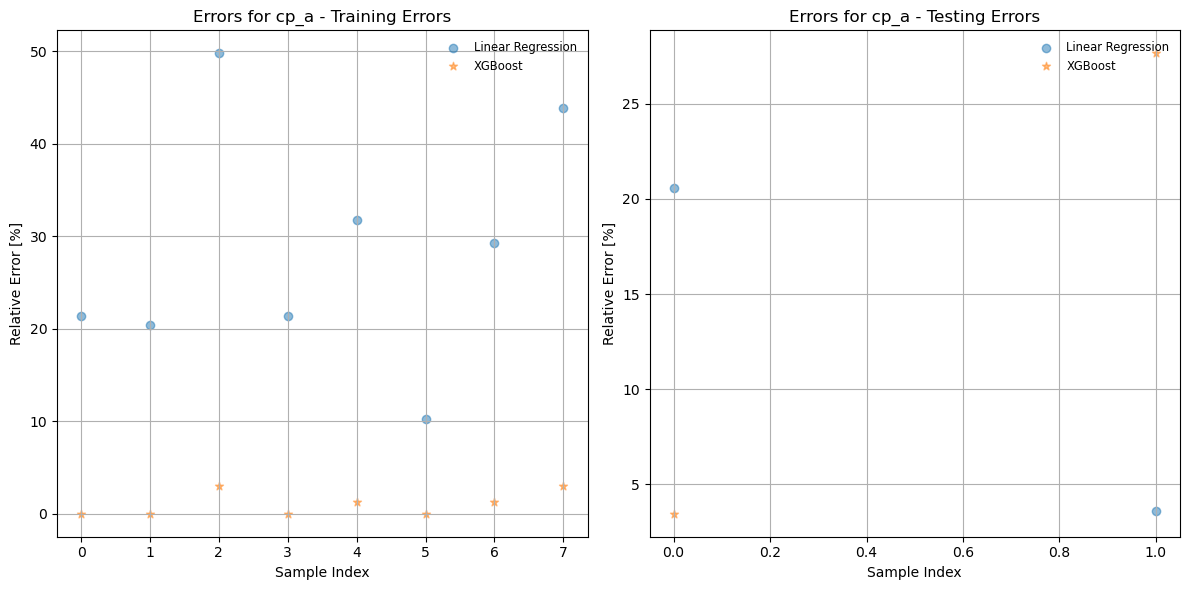

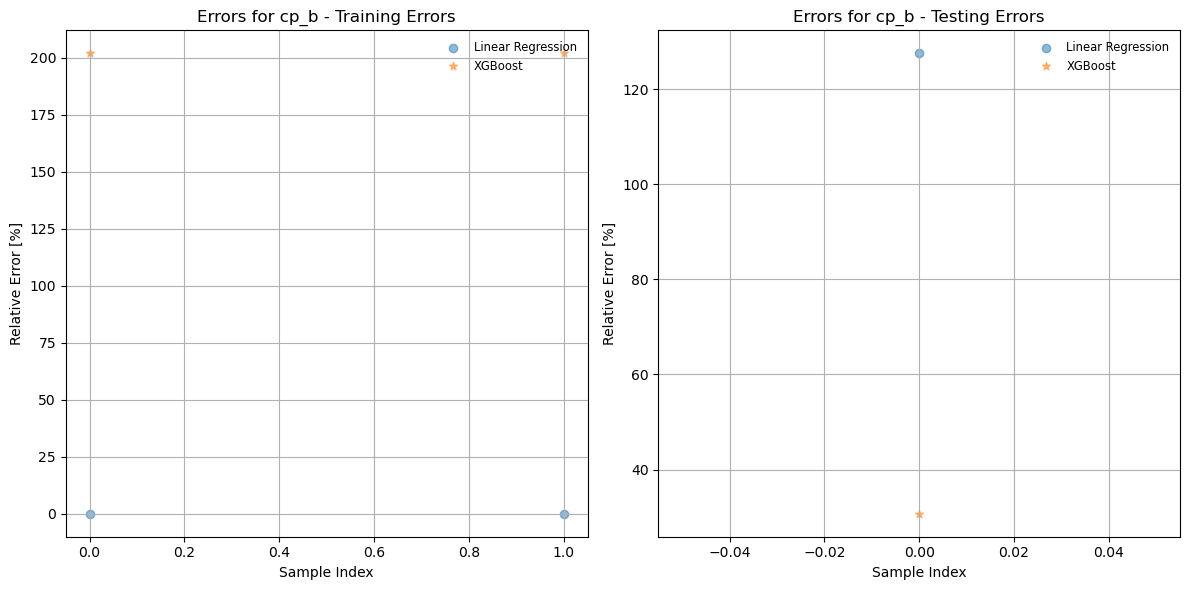

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

# Function to clean feature names
def clean_feature_names(columns):
    cleaned_columns = []
    for col in columns:
        col_str = str(col)  # Ensure it's a string
        col_str = col_str.replace('[', '').replace(']', '').replace('<', '').replace('>', '').replace(' ', '_')
        cleaned_columns.append(col_str)
    return cleaned_columns

# Assuming pred and tgt are your datasets
X = pred.copy()
X.columns = clean_feature_names(X.columns)

# Define available methods
# available_methods = ['Linear Regression', 
#                      'Polynomial Regression (degree 2)', 
#                      'Polynomial Regression (degree 3)', 
#                      'Polynomial Regression (degree 4)',
#                      'Decision Tree', 
#                      'Random Forest', 
#                      'XGBoost', 
#                      'SVR']

available_methods = ['Linear Regression', 'XGBoost']

# Select methods to visualize
selected_methods = available_methods  # You can modify this to select specific methods

results = {method: {} for method in selected_methods}

# Iterate over each column in tgt to predict one at a time
for column in tgt.columns:
    y = tgt[column].dropna()
    X_filtered = X.loc[y.index]

    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(X_filtered, y, test_size=0.2, random_state=42)

    # Store training errors for each method
    for method in selected_methods:
        results[method][column] = {}

    # 1. Linear Regression
    lin_reg = LinearRegression()
    lin_reg.fit(X_train, y_train)
    y_pred_lin_train = lin_reg.predict(X_train)
    y_pred_lin_test = lin_reg.predict(X_test)
    results['Linear Regression'][column] = (y_train, y_pred_lin_train, y_test, y_pred_lin_test)

    # Polynomial Regression
    for degree in [2, 3, 4]:
        if f'Polynomial Regression (degree {degree})' in selected_methods:
            poly_features = PolynomialFeatures(degree=degree)
            X_poly_train = poly_features.fit_transform(X_train)
            X_poly_test = poly_features.transform(X_test)
            lin_reg.fit(X_poly_train, y_train)
            y_pred_poly_train = lin_reg.predict(X_poly_train)
            y_pred_poly_test = lin_reg.predict(X_poly_test)
            results[f'Polynomial Regression (degree {degree})'][column] = (y_train, y_pred_poly_train, y_test, y_pred_poly_test)

    # 2. Decision Tree
    if 'Decision Tree' in selected_methods:
        tree_reg = DecisionTreeRegressor()
        tree_reg.fit(X_train, y_train)
        y_pred_tree_train = tree_reg.predict(X_train)
        y_pred_tree_test = tree_reg.predict(X_test)
        results['Decision Tree'][column] = (y_train, y_pred_tree_train, y_test, y_pred_tree_test)

    # 3. Random Forest
    if 'Random Forest' in selected_methods:
        forest_reg = RandomForestRegressor(n_estimators=100)
        forest_reg.fit(X_train, y_train)
        y_pred_forest_train = forest_reg.predict(X_train)
        y_pred_forest_test = forest_reg.predict(X_test)
        results['Random Forest'][column] = (y_train, y_pred_forest_train, y_test, y_pred_forest_test)

    # 4. XGBoost
    if 'XGBoost' in selected_methods:
        xgb_reg = xgb.XGBRegressor()
        xgb_reg.fit(X_train, y_train)
        y_pred_xgb_train = xgb_reg.predict(X_train)
        y_pred_xgb_test = xgb_reg.predict(X_test)
        results['XGBoost'][column] = (y_train, y_pred_xgb_train, y_test, y_pred_xgb_test)

    # 5. Support Vector Regression
    if 'SVR' in selected_methods:
        svr_reg = SVR()
        svr_reg.fit(X_train, y_train)
        y_pred_svr_train = svr_reg.predict(X_train)
        y_pred_svr_test = svr_reg.predict(X_test)
        results['SVR'][column] = (y_train, y_pred_svr_train, y_test, y_pred_svr_test)

# Function to create side-by-side error plots for training and testing
def error_plot(y_true_train, y_pred_train, y_true_test, y_pred_test, title):
    plt.figure(figsize=(12, 6))

    # Define marker styles for each method
    marker_styles = {
        'Linear Regression': 'o',
        'Polynomial Regression (degree 2)': 's',
        'Polynomial Regression (degree 3)': 'D',
        'Polynomial Regression (degree 4)': '^',
        'Decision Tree': 'x',
        'Random Forest': 'P',
        'XGBoost': '*',
        'SVR': 'v'
    }

    # Plot training errors
    plt.subplot(1, 2, 1)
    for method in selected_methods:
        if method in results and column in results[method]:
            y_train, y_pred_train, y_test, y_pred_test = results[method][column]
            plt.scatter(np.arange(len(y_true_train)), np.abs(y_true_train - y_pred_train)/abs(np.mean(y_true_train))*100, 
                        alpha=0.5, marker=marker_styles[method], label=method)
    plt.xlabel('Sample Index')
    plt.ylabel('Relative Error [%]')
    plt.title(title + ' - Training Errors')
    plt.grid(True)
    plt.legend(loc='upper right', fontsize='small', frameon=False)

    # Plot testing errors
    plt.subplot(1, 2, 2)
    for method in selected_methods:
        if method in results and column in results[method]:
            y_train, y_pred_train, y_test, y_pred_test = results[method][column]
            plt.scatter(np.arange(len(y_true_test)), np.abs(y_true_test - y_pred_test)/abs(np.mean(y_true_test))*100, 
                        alpha=0.5, marker=marker_styles[method], label=method)
    plt.xlabel('Sample Index')
    plt.ylabel('Relative Error [%]')
    plt.title(title + ' - Testing Errors')
    plt.grid(True)
    plt.legend(loc='upper right', fontsize='small', frameon=False)

    plt.tight_layout()
    plt.show()

# Generate error plots for selected methods and each column
for column in tgt.columns:
    # Call the error plot function for each target column
    # for method in selected_methods:
        # if method in results and column in results[method]:
    y_train, y_pred_train, y_test, y_pred_test = results[method][column]
    error_plot(y_train, y_pred_train, y_test, y_pred_test, f'Errors for {column}')

In [33]:
y_train

33      452.0
82      883.0
638     991.0
501     999.0
47      959.0
        ...  
221     755.0
451     867.0
529     812.0
663    1004.0
217     892.0
Name: Melt(K), Length: 365, dtype: float64

Error evaluating {'Gd': nan, 'Cl': 0.99}: malformed node or string: <ast.Name object at 0x115dc98b0>
Error evaluating {'Nd': nan, 'Cl': 0.99}: malformed node or string: <ast.Name object at 0x115dc9e50>
Error evaluating {'Np': nan, 'Cl': 0.99}: malformed node or string: <ast.Name object at 0x115dc97f0>
Error evaluating {'Pu': nan, 'Cl': 0.99}: malformed node or string: <ast.Name object at 0x115dc9d00>
Error evaluating {'Th': nan, 'Cl': 0.99}: malformed node or string: <ast.Name object at 0x1155e25b0>
Error evaluating {'U': nan, 'Cl': 0.99}: malformed node or string: <ast.Name object at 0x1155e2f70>
Error evaluating {'U': nan, 'Cl': 0.99}: malformed node or string: <ast.Name object at 0x1155e2700>
Error evaluating {'K': 1.96, 'Cl': 0.99, 'U': nan}: malformed node or string: <ast.Name object at 0x1155e2d30>
Error evaluating {'K': 1.96, 'Cl': 0.99, 'U': nan}: malformed node or string: <ast.Name object at 0x1155e2940>
Error evaluating {'K': 1.96, 'Cl': 0.99, 'U': nan}: malformed node or str

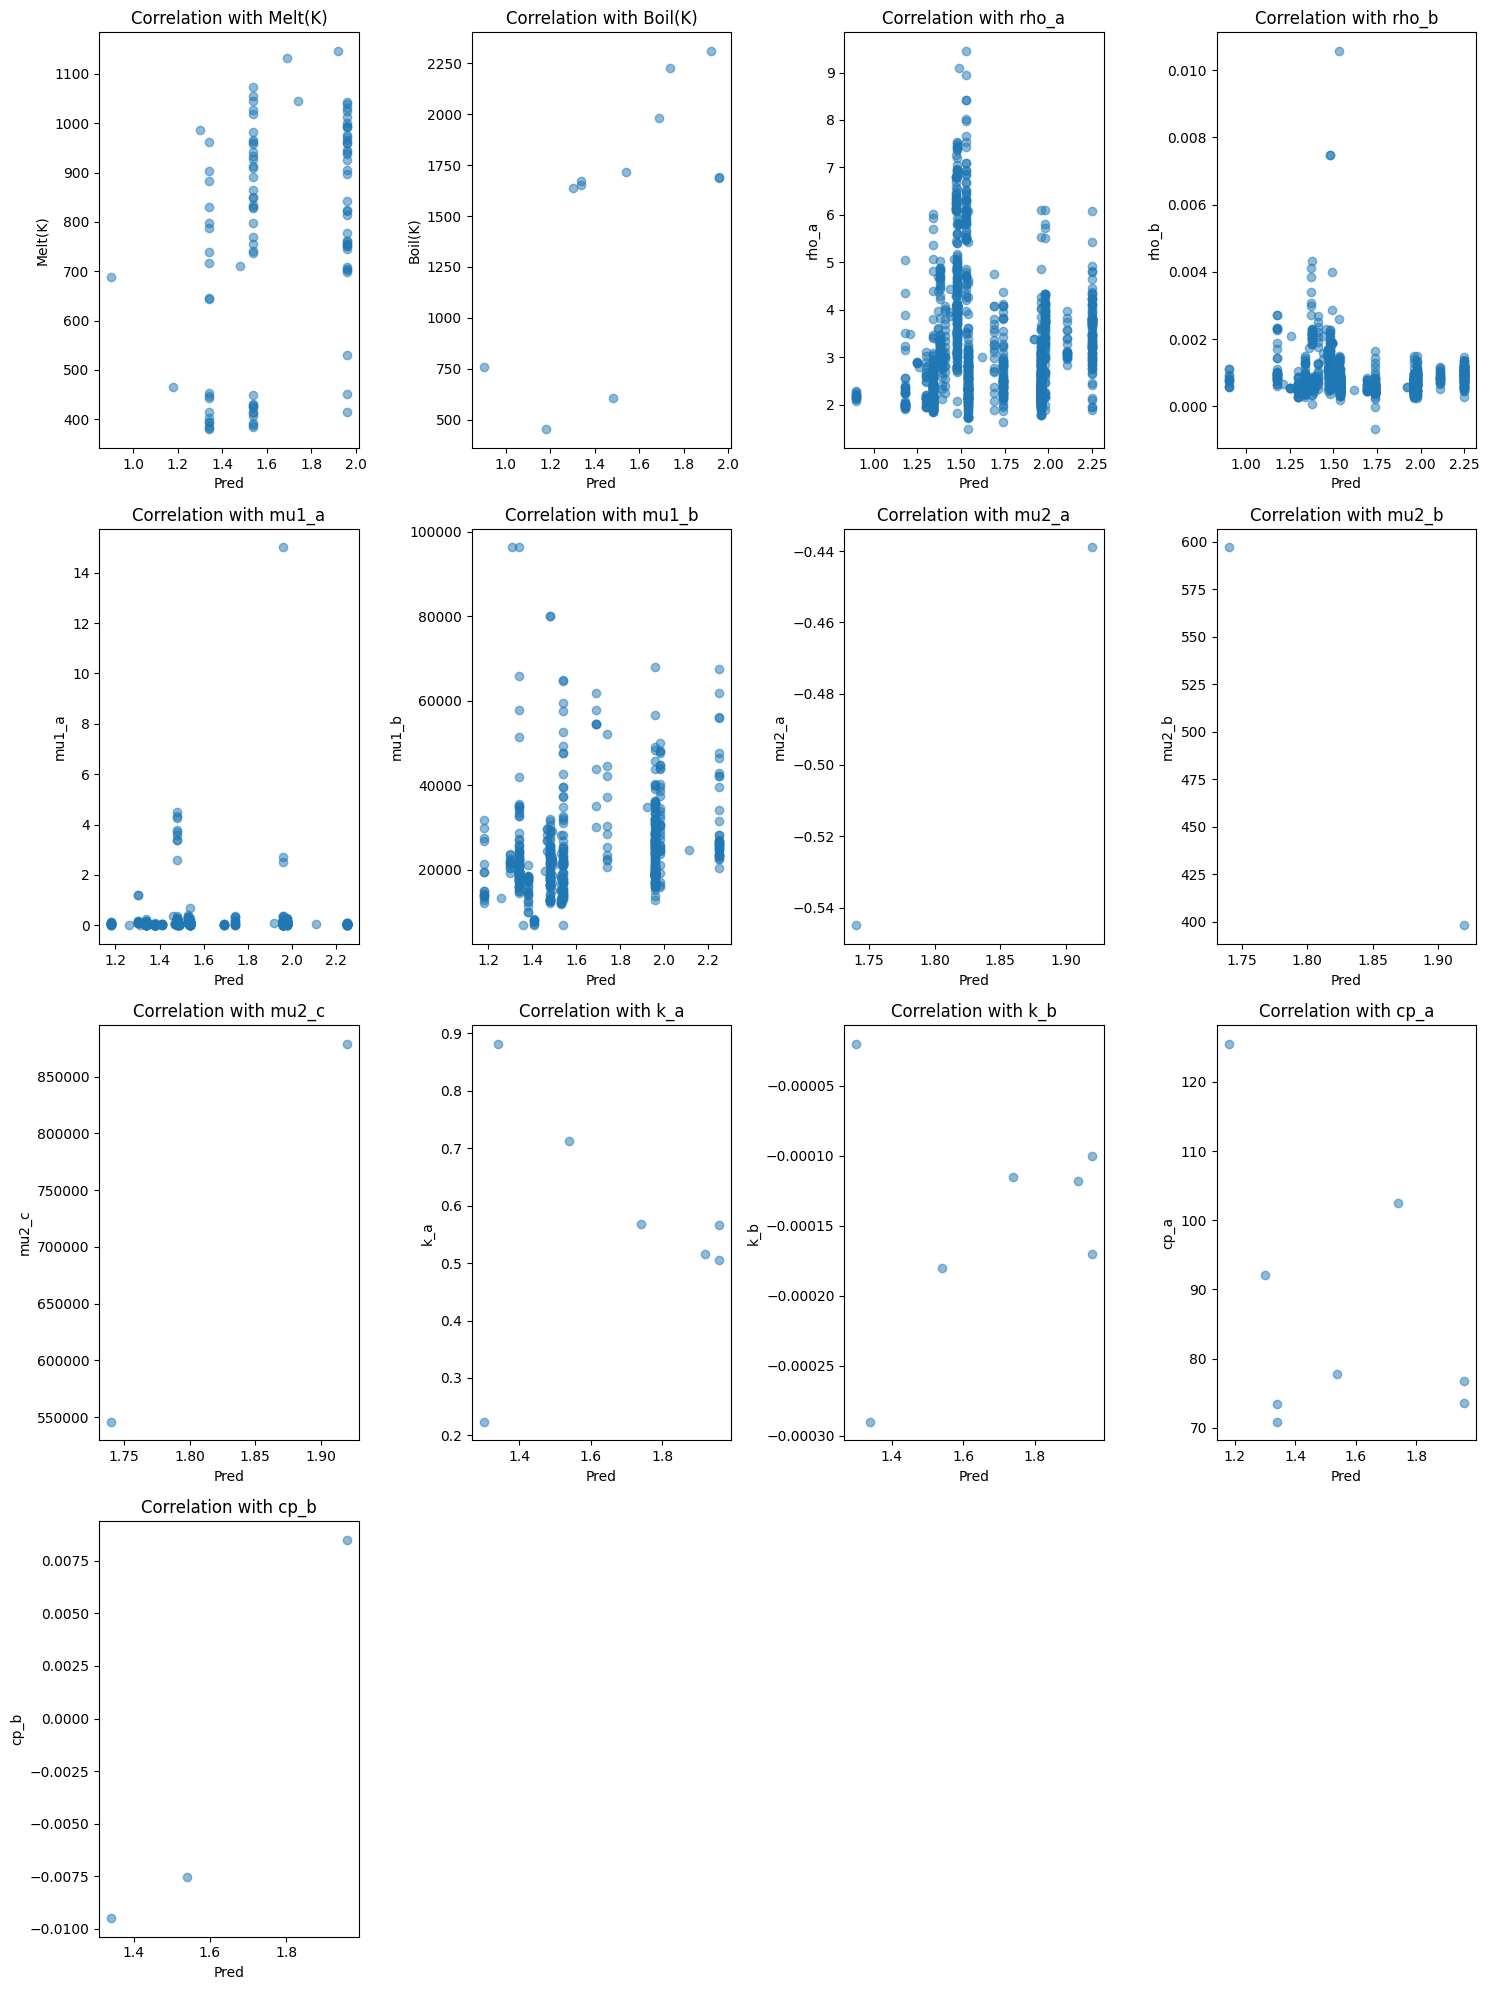

Correlation Table:
        Correlation
Melt(K)    0.382525
Boil(K)    0.667653
rho_a     -0.099922
rho_b     -0.165922
mu1_a     -0.014598
mu1_b      0.253606
mu2_a           1.0
mu2_b          -1.0
mu2_c           1.0
k_a       -0.077088
k_b        0.142214
cp_a       -0.38814
cp_b        0.97526


In [ ]:
def safe_eval(x):
    try:
        value = ast.literal_eval(x)
        keys = value.keys()
        cats = [key for key in keys if key != 'Cl']
        return value[cats[0]]
    except Exception as e:
        print(f"Error evaluating {x}: {e}")
        return None

# Assuming 'data' is your DataFrame and 'data_cols' and 'pred_cols' are lists containing the relevant columns.
pred = data[data_cols[6]].apply(safe_eval)
tgt = data[pred_cols]

# Prepare the plotting grid
n_cols = 4
n_rows = (len(tgt.columns) + 1) // n_cols + 1

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

correlation_table = pd.DataFrame(index=tgt.columns, columns=['Correlation'])

for i, column in enumerate(tgt.columns):
    not_nan_indices = tgt[column].notna()
    filtered_pred = pred[not_nan_indices]
    filtered_tgt = tgt[column][not_nan_indices]

    axes[i].scatter(filtered_pred, filtered_tgt, alpha=0.5)
    axes[i].set_title(f'Correlation with {column}')
    axes[i].set_xlabel('Pred')
    axes[i].set_ylabel(column)

    # Calculate and store the correlation coefficient
    correlation_coefficient = filtered_pred.corr(filtered_tgt)
    correlation_table.loc[column] = correlation_coefficient

# Remove any unused subplots if tgt columns are fewer than the grid size
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Output the final correlation table
print("Correlation Table:")
print(correlation_table)

In [ ]:
import pandas as pd



# Extract 'Cl' values from the dictionaries in the prediction dataframe
for column in prediction_df.columns:
    prediction_df[column + '_Cl'] = prediction_df[column].apply(lambda d: d.get('Cl', float('nan')))

# Drop original dictionary columns
prediction_df = prediction_df.drop(columns=list(prediction_df.columns[:len(prediction_df.columns) // 2]))

# Combine the target and prediction dataframes
combined_df = target_df.join(prediction_df)

# Compute correlation matrix
correlation_matrix = combined_df.corr()

# Display correlation matrix
print(correlation_matrix)

# Optionally, visualize the correlation matrix using seaborn
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()